<div style="
    background-color:#f4f6f7;
    border-left:6px solid #2c3e50;
    padding:20px;
    border-radius:10px;
    font-family:Arial, sans-serif;
">

<h2>Executive Summary</h2>

<h3>Objective</h3>
<p>
This analysis develops a complete actuarial model of a mid-sized pension fund,
covering mortality modeling, benefit projection, cashflow dynamics,
liability valuation, and funding requirements.
</p>

<hr>

<h3>Portfolio Characteristics</h3>

<ul>
<li><b>Population:</b> ~10,000 members</li>
<li><b>Actives:</b> ~6,000 (ages 25–64)</li>
<li><b>Retirees:</b> ~4,000 (ages 65–90)</li>
<li><b>Income segmentation:</b> low / mid / high</li>
<li><b>Fund type:</b> closed population (no new entrants)</li>
</ul>

<hr>

<h3>Mortality Modeling</h3>

<ul>
<li><b>Data source:</b> Human Mortality Database (HMD), Belgium</li>
<li><b>Year used:</b> most recent complete year (2024)</li>
<li><b>Approach:</b> exposure-weighted unisex mortality</li>
<li><b>Parametric model:</b> Gompertz–Makeham law</li>
<li><b>Segmentation:</b> income-based longevity differentials via parameter shifts</li>
</ul>

<p style="font-size:18px;">
\[
\mu(x) = A + B e^{C x}
\]
</p>

<hr>

<h3>Financial and Modeling Assumptions</h3>

<ul>
<li><b>Salary model:</b> lognormal distribution per income group</li>
<li><b>Salary growth:</b> 2.5% per year</li>
<li><b>Accrual rate:</b> 1.75% per service year</li>
<li><b>Retirement age:</b> stochastic around 65</li>
<li><b>Discount rate:</b> 2.0%</li>
</ul>

<hr>

<h3>Key Results</h3>

<ul>
<li><b>Best Estimate Liability (BEL):</b> ~4.33 billion EUR</li>
<li><b>Current Assets:</b> 3.75 billion EUR</li>
<li><b>Funding Ratio:</b> 86.7%</li>
<li><b>Funding Gap:</b> ~577 million EUR</li>
<li><b>Required Contribution Rate:</b> ~11.3% of salary</li>
</ul>

<p style="font-size:18px;">
\[
BEL = \sum_{t=0}^{T} \frac{CF_t}{(1+r)^t}
\]
</p>

<hr>

<h3>Cashflow Profile</h3>

<p>
Projected pension payments exhibit a delayed hump shape:
</p>

<ul>
<li>initial decline due to mortality of current retirees</li>
<li>increase driven by retirement of active members</li>
<li>final decline as the population runs off</li>
</ul>

<p>
This pattern is characteristic of a <b>mature, closed pension fund</b>.
</p>

<hr>

<h3>Sensitivity to Discount Rate</h3>

<ul>
<li>1.0% → severe deficit (≈29% contribution)</li>
<li>2.0% → moderate deficit (≈11%)</li>
<li>3.0% → apparent surplus</li>
</ul>

<p>
The funding position is highly sensitive to economic assumptions,
highlighting the importance of prudent discount rate selection.
</p>

<hr>

<h3>Key Insight</h3>

<p>
The primary value of modern Python tooling lies not in rewriting actuarial models,
but in enhancing them through:
</p>

<ul>
<li>model calibration (statistical fitting)</li>
<li>visualisation and insight generation</li>
<li>robust validation and testing frameworks</li>
<li>scenario analysis and simulation (e.g. Monte Carlo)</li>
</ul>

<hr>

<h3>Conclusion</h3>

<p>
The model provides a transparent and reproducible framework for pension fund analysis.
It demonstrates how demographic dynamics, financial assumptions,
and modeling choices interact in determining long-term sustainability.
</p>

<p>
It also highlights that funding decisions should not rely on single-point estimates,
but must account for uncertainty and sensitivity to key assumptions.
</p>

</div>


In [1]:
# ============================================================
# Title: Act 0 — Environment & HMD Data Validation
# Cell: 0
# Version: 1.0
# Date: 2026-04-27
# Description:
# Verify required Python libraries and ensure HMD mortality
# files are present locally. No automatic download is attempted.
# ============================================================

import sys
import importlib
import subprocess
from pathlib import Path


# ------------------------------------------------------------
# 0.1 — Package Verification
# ------------------------------------------------------------

def verify_packages():
    print("\n--- 0.1: Package Verification ---")

    requirements = [
        "numpy",
        "pandas",
        "matplotlib",
        "scipy",
        "aggregate"
    ]

    missing = []

    for pkg in requirements:
        try:
            importlib.import_module(pkg)
            print(f"✅ {pkg} detected.")
        except ImportError:
            print(f"❌ {pkg} missing.")
            missing.append(pkg)

    if missing:
        print(f"\n📦 Missing packages: {', '.join(missing)}")
        user_input = input("Install now via pip? (y/n): ").strip().lower()

        if user_input == "y":
            subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])
            print("✨ Installation complete. Restart kernel recommended.")
        else:
            raise RuntimeError(
                "Required packages missing. Aborting to ensure reproducibility."
            )

    print("✔ Environment OK.")


# ------------------------------------------------------------
# 0.2 — HMD File Validation
# ------------------------------------------------------------

def verify_hmd_files():
    print("\n--- 0.2: HMD Data Validation ---")

    hmd_dir = Path("./data/hmd")

    deaths_file = hmd_dir / "Deaths_1x1.txt"
    exposures_file = hmd_dir / "Exposures_1x1.txt"

    if not hmd_dir.exists():
        raise FileNotFoundError(
            f"HMD directory not found: {hmd_dir}\n"
            "Expected structure:\n"
            "  ./data/hmd/Deaths_1x1.txt\n"
            "  ./data/hmd/Exposures_1x1.txt"
        )

    errors = []

    if not deaths_file.exists():
        errors.append("Deaths_1x1.txt missing")

    if not exposures_file.exists():
        errors.append("Exposures_1x1.txt missing")

    if errors:
        raise FileNotFoundError(
            "HMD file validation failed:\n"
            + "\n".join(f" - {e}" for e in errors)
        )

    print("✅ HMD files detected:")
    print(f"   - {deaths_file.resolve()}")
    print(f"   - {exposures_file.resolve()}")

    # Optional sanity check: file size
    if deaths_file.stat().st_size < 1_000:
        raise ValueError("Deaths file looks suspiciously small.")
    if exposures_file.stat().st_size < 1_000:
        raise ValueError("Exposures file looks suspiciously small.")

    print("✔ HMD data ready.")


# ------------------------------------------------------------
# Execution
# ------------------------------------------------------------

verify_packages()
verify_hmd_files()

print("\n🚀 Workspace ready for Act 1.")


--- 0.1: Package Verification ---
✅ numpy detected.
✅ pandas detected.
✅ matplotlib detected.
✅ scipy detected.
✅ aggregate detected.
✔ Environment OK.

--- 0.2: HMD Data Validation ---
✅ HMD files detected:
   - C:\Users\Erik VAN RELEGHEM\PensionFund\data\hmd\Deaths_1x1.txt
   - C:\Users\Erik VAN RELEGHEM\PensionFund\data\hmd\Exposures_1x1.txt
✔ HMD data ready.

🚀 Workspace ready for Act 1.


In [2]:
# ============================================================
# Title: Act 1 — HMD Belgium: Robust File Loader
# Cell: 1
# Version: 1.0
# Date: 2026-04-27
# Description:
# Load HMD 1x1 deaths and exposures files from local text files.
# The loader locates the HMD table header and reads the whitespace-
# delimited data into pandas dataframes.
# ============================================================

from pathlib import Path
import pandas as pd


HMD_DIR = Path("./data/hmd")
DEATHS_FILE = HMD_DIR / "Deaths_1x1.txt"
EXPOSURES_FILE = HMD_DIR / "Exposures_1x1.txt"


def load_hmd_1x1_file(path: Path) -> pd.DataFrame:
    """
    Load an HMD 1x1 text file.

    Expected table structure:
        Year  Age  Female  Male  Total

    The HMD file contains descriptive text before the actual table.
    This function finds the row starting with 'Year' and reads from there.
    """

    with path.open("r", encoding="utf-8", errors="replace") as f:
        lines = f.readlines()

    header_idx = None

    for i, line in enumerate(lines):
        if line.strip().startswith("Year"):
            header_idx = i
            break

    if header_idx is None:
        raise ValueError(f"Could not locate HMD data header in file: {path}")

    df = pd.read_csv(
        path,
        sep=r"\s+",
        skiprows=header_idx,
        engine="python"
    )

    expected_cols = ["Year", "Age", "Female", "Male", "Total"]
    missing_cols = [col for col in expected_cols if col not in df.columns]

    if missing_cols:
        raise ValueError(
            f"Unexpected HMD file structure in {path}. "
            f"Missing columns: {missing_cols}"
        )

    return df[expected_cols].copy()


deaths_raw = load_hmd_1x1_file(DEATHS_FILE)
exposures_raw = load_hmd_1x1_file(EXPOSURES_FILE)

print("HMD files loaded successfully.")
print(f"Deaths rows   : {len(deaths_raw):,}")
print(f"Exposures rows: {len(exposures_raw):,}")

display(deaths_raw.head())
display(exposures_raw.head())

HMD files loaded successfully.
Deaths rows   : 20,424
Exposures rows: 20,424


,Year,Age,Female,Male,Total
0,1841,0,9248.00,11741.00,20989.00
1,1841,1,4126.00,4156.00,8282.00
2,1841,2,2147.00,2092.00,4239.00
3,1841,3,1241.00,1155.00,2396.00
4,1841,4,869.00,817.00,1686.00


,Year,Age,Female,Male,Total
0,1841,0,61006.15,62948.23,123954.38
1,1841,1,55072.53,56064.21,111136.73
2,1841,2,51480.76,52521.70,104002.46
3,1841,3,48750.57,49506.71,98257.28
4,1841,4,47014.08,47861.81,94875.89


In [3]:
# ============================================================
# Title: Act 1 — HMD Belgium: Data Cleaning
# Cell: 2
# Version: 1.0
# Date: 2026-04-27
# Description:
# Clean raw HMD deaths and exposures tables by converting
# Year, Age, Female, Male, and Total to numeric values.
# Open-ended ages such as 110+ are excluded.
# ============================================================

def clean_hmd_table(df: pd.DataFrame, value_name: str) -> pd.DataFrame:
    """
    Clean an HMD 1x1 table.

    Parameters
    ----------
    df:
        Raw HMD dataframe with columns Year, Age, Female, Male, Total.

    value_name:
        Name used only for documentation at this stage.

    Returns
    -------
    pd.DataFrame
        Clean dataframe with numeric Year, Age, Female, Male, Total.
    """

    clean = df.copy()

    clean["Year"] = pd.to_numeric(clean["Year"], errors="coerce")
    clean["Age"] = pd.to_numeric(clean["Age"], errors="coerce")

    for col in ["Female", "Male", "Total"]:
        clean[col] = pd.to_numeric(clean[col], errors="coerce")

    clean = clean.dropna(subset=["Year", "Age", "Female", "Male", "Total"])

    clean["Year"] = clean["Year"].astype(int)
    clean["Age"] = clean["Age"].astype(int)

    clean = clean.sort_values(["Year", "Age"]).reset_index(drop=True)

    assert not clean.empty, f"{value_name} table is empty after cleaning."
    assert clean["Year"].min() >= 1800, f"{value_name}: suspicious minimum year."
    assert clean["Age"].min() >= 0, f"{value_name}: negative ages found."
    assert clean[["Female", "Male", "Total"]].ge(0).all().all(), (
        f"{value_name}: negative values found."
    )

    return clean


deaths_clean = clean_hmd_table(deaths_raw, "Deaths")
exposures_clean = clean_hmd_table(exposures_raw, "Exposures")

print("HMD tables cleaned successfully.")
print(f"Deaths clean rows   : {len(deaths_clean):,}")
print(f"Exposures clean rows: {len(exposures_clean):,}")

display(deaths_clean.head())
display(deaths_clean.tail())
display(exposures_clean.head())
display(exposures_clean.tail())

HMD tables cleaned successfully.
Deaths clean rows   : 19,690
Exposures clean rows: 19,690


,Year,Age,Female,Male,Total
0,1841,0,9248.0,11741.0,20989.0
1,1841,1,4126.0,4156.0,8282.0
2,1841,2,2147.0,2092.0,4239.0
3,1841,3,1241.0,1155.0,2396.0
4,1841,4,869.0,817.0,1686.0


,Year,Age,Female,Male,Total
19685,2024,105,26.0,6.0,32.0
19686,2024,106,13.0,0.0,13.0
19687,2024,107,4.0,4.0,8.0
19688,2024,108,3.0,0.0,3.0
19689,2024,109,2.0,0.0,2.0


,Year,Age,Female,Male,Total
0,1841,0,61006.15,62948.23,123954.38
1,1841,1,55072.53,56064.21,111136.73
2,1841,2,51480.76,52521.70,104002.46
3,1841,3,48750.57,49506.71,98257.28
4,1841,4,47014.08,47861.81,94875.89


,Year,Age,Female,Male,Total
19685,2024,105,38.88,5.39,44.27
19686,2024,106,15.97,2.99,18.96
19687,2024,107,8.25,1.80,10.05
19688,2024,108,3.93,0.40,4.33
19689,2024,109,1.98,0.00,1.98


In [4]:
# ============================================================
# Title: Act 1 — Merge & Clean Mortality (Robust)
# Cell: 3 (REVISED)
# Version: 1.1
# Date: 2026-04-27
# Description:
# Merge deaths and exposures and compute mortality rates.
# Remove invalid rows based on exposure and qx constraints.
# ============================================================

import numpy as np

mortality = deaths_clean.merge(
    exposures_clean,
    on=["Year", "Age"],
    suffixes=("_D", "_E")
)

# Compute crude mortality
for sex in ["Female", "Male", "Total"]:
    mortality[f"q_{sex}"] = mortality[f"{sex}_D"] / mortality[f"{sex}_E"]

# ------------------------------------------------------------
# CLEANING RULES (critical)
# ------------------------------------------------------------

# 1. Exposure must be strictly positive
for sex in ["Female", "Male", "Total"]:
    mortality = mortality[mortality[f"{sex}_E"] > 0]

# 2. Remove NaN / inf
rate_cols = ["q_Female", "q_Male", "q_Total"]
mortality = mortality.replace([np.inf, -np.inf], np.nan)
mortality = mortality.dropna(subset=rate_cols)

# 3. Mortality must be in [0,1]
for col in rate_cols:
    mortality = mortality[(mortality[col] >= 0) & (mortality[col] <= 1)]

# Final check
assert not mortality.empty, "Mortality table is empty after cleaning."

print("Mortality table constructed and cleaned.")
print(f"Rows: {len(mortality):,}")

display(mortality.head())
display(mortality.tail())

Mortality table constructed and cleaned.
Rows: 18,328


,Year,Age,Female_D,Male_D,Total_D,Female_E,Male_E,Total_E,q_Female,q_Male,q_Total
0,1841,0,9248.0,11741.0,20989.0,61006.15,62948.23,123954.38,0.151591,0.186518,0.169328
1,1841,1,4126.0,4156.0,8282.0,55072.53,56064.21,111136.73,0.074919,0.074129,0.074521
2,1841,2,2147.0,2092.0,4239.0,51480.76,52521.70,104002.46,0.041705,0.039831,0.040759
3,1841,3,1241.0,1155.0,2396.0,48750.57,49506.71,98257.28,0.025456,0.023330,0.024385
4,1841,4,869.0,817.0,1686.0,47014.08,47861.81,94875.89,0.018484,0.017070,0.017771


,Year,Age,Female_D,Male_D,Total_D,Female_E,Male_E,Total_E,q_Female,q_Male,q_Total
19682,2024,102,198.0,37.0,235.0,386.86,67.76,454.63,0.511813,0.546045,0.516904
19683,2024,103,108.0,26.0,134.0,222.24,33.55,255.78,0.485961,0.774963,0.523888
19684,2024,104,62.0,5.0,67.0,126.00,16.28,142.28,0.492063,0.307125,0.470902
19686,2024,106,13.0,0.0,13.0,15.97,2.99,18.96,0.814026,0.000000,0.685654
19688,2024,108,3.0,0.0,3.0,3.93,0.40,4.33,0.763359,0.000000,0.692841


In [5]:
# ============================================================
# Title: Act 1 — Select Latest Complete Mortality Year
# Cell: 4
# Version: 1.0
# Date: 2026-04-27
# Description:
# Identify the most recent year with complete mortality
# coverage across all ages.
# ============================================================

AGE_MIN = 25
AGE_MAX = 100

def is_complete_year(df, year):
    subset = df[df["Year"] == year]

    ages_present = set(subset["Age"])
    required_ages = set(range(AGE_MIN, AGE_MAX + 1))

    return required_ages.issubset(ages_present)


years = sorted(mortality["Year"].unique(), reverse=True)

complete_years = [y for y in years if is_complete_year(mortality, y)]

assert len(complete_years) > 0, "No complete mortality year found."

MORTALITY_YEAR = complete_years[0]

mortality_year = mortality[mortality["Year"] == MORTALITY_YEAR].copy()

print(f"Selected mortality year: {MORTALITY_YEAR}")
print(f"Rows in selected year: {len(mortality_year)}")

display(mortality_year.head())
display(mortality_year.tail())

Selected mortality year: 2024
Rows in selected year: 107


,Year,Age,Female_D,Male_D,Total_D,Female_E,Male_E,Total_E,q_Female,q_Male,q_Total
19580,2024,0,165.0,213.0,378.0,54390.90,56525.70,110916.60,0.003034,0.003768,0.003408
19581,2024,1,16.0,10.0,26.0,56539.39,59165.56,115704.94,0.000283,0.000169,0.000225
19582,2024,2,8.0,8.0,16.0,60059.50,62819.73,122879.23,0.000133,0.000127,0.000130
19583,2024,3,7.0,5.0,12.0,57087.97,59722.16,116810.12,0.000123,0.000084,0.000103
19584,2024,4,4.0,6.0,10.0,60279.25,62440.89,122720.14,0.000066,0.000096,0.000081


,Year,Age,Female_D,Male_D,Total_D,Female_E,Male_E,Total_E,q_Female,q_Male,q_Total
19682,2024,102,198.0,37.0,235.0,386.86,67.76,454.63,0.511813,0.546045,0.516904
19683,2024,103,108.0,26.0,134.0,222.24,33.55,255.78,0.485961,0.774963,0.523888
19684,2024,104,62.0,5.0,67.0,126.00,16.28,142.28,0.492063,0.307125,0.470902
19686,2024,106,13.0,0.0,13.0,15.97,2.99,18.96,0.814026,0.000000,0.685654
19688,2024,108,3.0,0.0,3.0,3.93,0.40,4.33,0.763359,0.000000,0.692841


In [6]:
# ============================================================
# Title: Act 1 — Restrict to Modeling Age Range
# Cell: 4B
# Version: 1.0
# Date: 2026-04-27
# Description:
# Restrict selected mortality year to ages 25–100.
# ============================================================

mortality_year = mortality_year[
    (mortality_year["Age"] >= AGE_MIN) &
    (mortality_year["Age"] <= AGE_MAX)
].copy()

mortality_year = mortality_year.sort_values("Age").reset_index(drop=True)

# Validation
expected_rows = AGE_MAX - AGE_MIN + 1

assert len(mortality_year) == expected_rows, (
    f"Unexpected number of ages: {len(mortality_year)} (expected {expected_rows})"
)

assert mortality_year["Age"].min() == AGE_MIN
assert mortality_year["Age"].max() == AGE_MAX

print(f"Filtered to ages {AGE_MIN}–{AGE_MAX}")
print(f"Rows: {len(mortality_year)}")

display(mortality_year.head())
display(mortality_year.tail())

Filtered to ages 25–100
Rows: 76


,Year,Age,Female_D,Male_D,Total_D,Female_E,Male_E,Total_E,q_Female,q_Male,q_Total
0,2024,25,9.0,46.0,55.0,70857.00,72497.76,143354.76,0.000127,0.000635,0.000384
1,2024,26,12.0,51.0,63.0,72251.92,73099.94,145351.86,0.000166,0.000698,0.000433
2,2024,27,17.0,41.0,58.0,73294.46,74223.15,147517.61,0.000232,0.000552,0.000393
3,2024,28,16.0,39.0,55.0,72879.58,73881.02,146760.60,0.000220,0.000528,0.000375
4,2024,29,20.0,58.0,78.0,73185.90,74598.71,147784.61,0.000273,0.000777,0.000528


,Year,Age,Female_D,Male_D,Total_D,Female_E,Male_E,Total_E,q_Female,q_Male,q_Total
71,2024,96,1393.0,595.0,1988.0,4924.19,1584.07,6508.26,0.282889,0.375615,0.305458
72,2024,97,1161.0,351.0,1512.0,3503.84,1016.41,4520.25,0.331351,0.345333,0.334495
73,2024,98,836.0,276.0,1112.0,2443.25,654.11,3097.36,0.342167,0.421947,0.359015
74,2024,99,660.0,193.0,853.0,1654.81,408.32,2063.12,0.398837,0.472668,0.413451
75,2024,100,441.0,116.0,557.0,1032.58,229.55,1262.14,0.427086,0.505337,0.441314


<div style="
    background-color:#eef7f1;
    border-left:6px solid #2e7d32;
    padding:16px;
    border-radius:10px;
    font-family:Arial, sans-serif;
">

<h3>Act 1 — Cell 5: Constructing Unisex Mortality</h3>

<h4>What we do</h4>
<p>
We construct a Belgian unisex mortality rate for each age by combining male and female
deaths and exposures.
</p>

<h4>Why it matters</h4>
<p>
A pension fund usually contains both men and women. A unisex mortality basis gives us
one common mortality table for the fund, while still being grounded in real HMD data.
</p>

<h4>Expected outcome</h4>
<p>
A clean table with one mortality rate per age:
</p>

<p style="font-size:18px;">
\[
q_x^{unisex}
=
\frac{D_x^{female} + D_x^{male}}
     {E_x^{female} + E_x^{male}}
\]
</p>

<p>
This is an exposure-weighted construction. It is not a simple average of male and female
mortality rates.
</p>

</div>

In [7]:
# ============================================================
# Title: Act 1 — Unisex Mortality Construction
# Cell: 5
# Version: 1.0
# Date: 2026-04-27
# Description:
# Construct exposure-weighted unisex mortality rates from
# male and female deaths and exposures.
# ============================================================

unisex = mortality_year.copy()

# Recompute (do NOT trust provided Total blindly)
unisex["Deaths_unisex"] = unisex["Female_D"] + unisex["Male_D"]
unisex["Exposure_unisex"] = unisex["Female_E"] + unisex["Male_E"]

unisex["qx"] = unisex["Deaths_unisex"] / unisex["Exposure_unisex"]

# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

assert unisex["Exposure_unisex"].gt(0).all(), "Zero exposure found."
assert unisex["qx"].between(0, 1).all(), "qx outside [0,1]"
assert unisex["qx"].notna().all(), "Missing qx values"

# Optional: check consistency with HMD Total
diff = (unisex["qx"] - unisex["q_Total"]).abs().max()

print(f"Max deviation vs HMD Total: {diff:.10f}")

print("\nUnisex mortality table ready.")
display(unisex[["Age", "qx"]].head())
display(unisex[["Age", "qx"]].tail())

Max deviation vs HMD Total: 0.0000034966

Unisex mortality table ready.


,Age,qx
0,25,0.000384
1,26,0.000433
2,27,0.000393
3,28,0.000375
4,29,0.000528


,Age,qx
71,96,0.305458
72,97,0.334495
73,98,0.359015
74,99,0.413449
75,100,0.441317


<div style="
    background-color:#eef4fb;
    border-left:6px solid #1565c0;
    padding:16px;
    border-radius:10px;
    font-family:Arial, sans-serif;
">

<h3>Act 1 — Cell 6: From Mortality to Survival</h3>

<h4>What we do</h4>
<p>
We convert mortality rates into survival probabilities. From the probability of dying
during a year, we derive the probability of surviving, and then construct a full
survival curve.
</p>

<h4>Why it matters</h4>
<p>
Pension liabilities depend on whether individuals are alive in the future.
Survival probabilities are therefore the core driver of all cashflow projections.
</p>

<h4>Expected outcome</h4>

<p>
We compute:
</p>

<p style="font-size:18px;">
\[
p_x = 1 - q_x
\]
</p>

<p>
and the survival function:
</p>

<p style="font-size:18px;">
\[
S_x = \prod_{k=25}^{x-1} p_k
\]
</p>

<p>
which represents the probability of being alive at age \(x\), given survival to age 25.
</p>

</div>

In [8]:
# ============================================================
# Title: Act 1 — Survival Curve Construction
# Cell: 6
# Version: 1.0
# Date: 2026-04-27
# Description:
# Convert mortality rates qx into survival probabilities px
# and build the survival function Sx.
# ============================================================

survival = unisex[["Age", "qx"]].copy()

# Step 1: survival probability per year
survival["px"] = 1.0 - survival["qx"]

# Step 2: cumulative survival from age 25
survival["Sx"] = survival["px"].cumprod().shift(1, fill_value=1.0)

# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

assert survival["px"].between(0, 1).all(), "px outside [0,1]"
assert survival["Sx"].between(0, 1).all(), "Sx outside [0,1]"
assert survival["Sx"].is_monotonic_decreasing, "Survival must decrease"

print("Survival curve constructed.")
display(survival.head())
display(survival.tail())

Survival curve constructed.


,Age,qx,px,Sx
0,25,0.000384,0.999616,1.000000
1,26,0.000433,0.999567,0.999616
2,27,0.000393,0.999607,0.999183
3,28,0.000375,0.999625,0.998790
4,29,0.000528,0.999472,0.998416


,Age,qx,px,Sx
71,96,0.305458,0.694542,0.075977
72,97,0.334495,0.665505,0.052769
73,98,0.359015,0.640985,0.035118
74,99,0.413449,0.586551,0.022510
75,100,0.441317,0.558683,0.013203


<div style="
    background-color:#fff8e1;
    border-left:6px solid #f9a825;
    padding:16px;
    border-radius:10px;
    font-family:Arial, sans-serif;
">

<h3>Act 1 — Cell 7: Visual Inspection of Mortality and Survival</h3>

<h4>What we do</h4>
<p>
We visualize the empirical Belgian unisex mortality curve and the corresponding survival curve.
</p>

<h4>Why it matters</h4>
<p>
Before fitting a parametric mortality law, we must inspect the raw actuarial basis.
The mortality curve should increase with age, while the survival curve should decline smoothly.
</p>

<h4>Expected outcome</h4>
<p>
Two professional diagnostic graphs:
</p>

<ul>
<li>\(q_x\): annual mortality rate by age, shown on a logarithmic scale</li>
<li>\(S_x\): survival probability from age 25</li>
</ul>

</div>

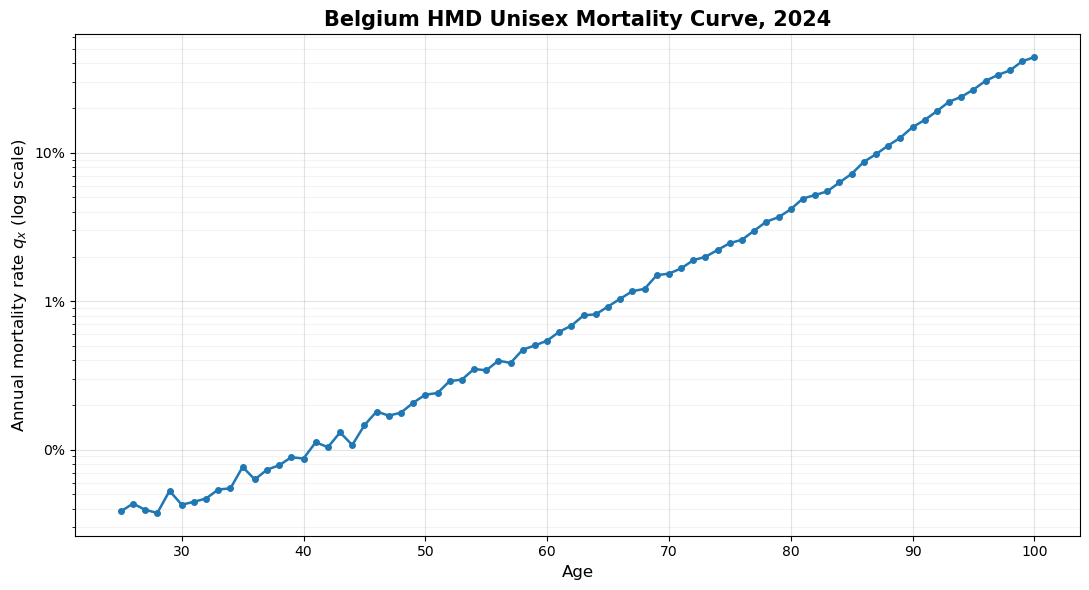

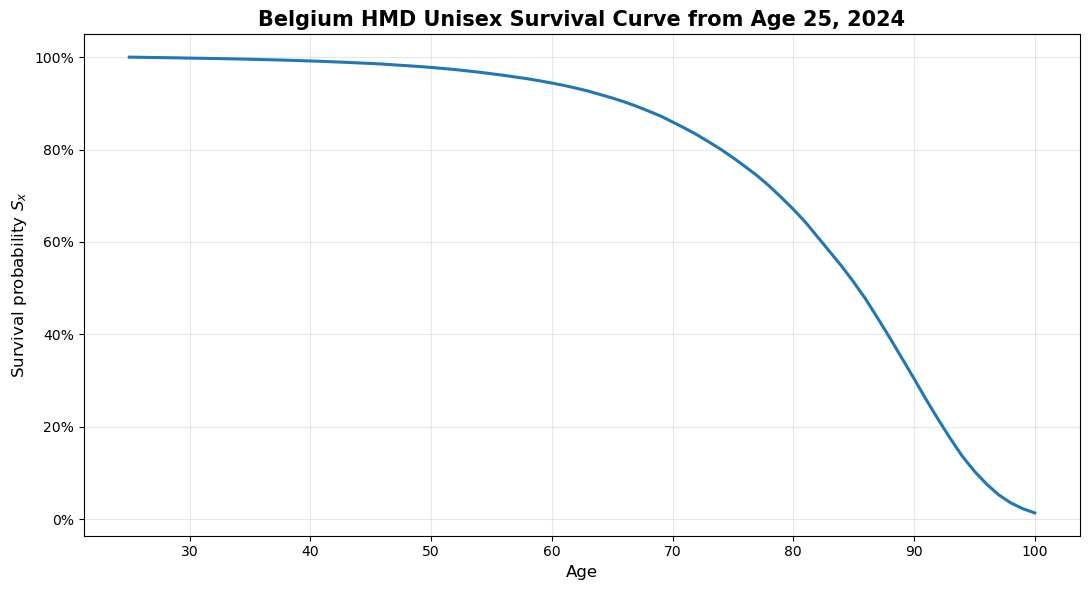

In [9]:
# ============================================================
# Title: Act 1 — Mortality and Survival Visualisation
# Cell: 7
# Version: 1.0
# Date: 2026-04-27
# Description:
# Produce professional diagnostic charts for the Belgian
# unisex mortality curve and survival curve.
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# ------------------------------------------------------------
# Chart 1 — Mortality curve qx
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(
    unisex["Age"],
    unisex["qx"],
    marker="o",
    linewidth=1.8,
    markersize=4
)

ax.set_yscale("log")

ax.set_title(
    f"Belgium HMD Unisex Mortality Curve, {MORTALITY_YEAR}",
    fontsize=15,
    weight="bold"
)

ax.set_xlabel("Age", fontsize=12)
ax.set_ylabel(r"Annual mortality rate $q_x$ (log scale)", fontsize=12)

ax.grid(True, which="major", alpha=0.35)
ax.grid(True, which="minor", alpha=0.15)

ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Chart 2 — Survival curve Sx
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(
    survival["Age"],
    survival["Sx"],
    linewidth=2.2
)

ax.set_title(
    f"Belgium HMD Unisex Survival Curve from Age {AGE_MIN}, {MORTALITY_YEAR}",
    fontsize=15,
    weight="bold"
)

ax.set_xlabel("Age", fontsize=12)
ax.set_ylabel(r"Survival probability $S_x$", fontsize=12)

ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))

ax.grid(True, alpha=0.30)

plt.tight_layout()
plt.show()

<div style="
    background-color:#f7fbff;
    border-left:6px solid #1565c0;
    padding:16px;
    border-radius:10px;
    font-family:Arial, sans-serif;
">

<h3>Interpretation — Mortality and Survival</h3>

<p>
The empirical Belgian mortality curve exhibits the expected actuarial structure:
</p>

<ul>
<li>Very low mortality in early adult ages (≈ 0.03–0.05%)</li>
<li>Exponential increase with age</li>
<li>High mortality beyond age 90</li>
</ul>

<p>
The survival curve shows that:
</p>

<ul>
<li>Survival remains close to 100% until middle ages</li>
<li>Decline accelerates after age 70</li>
<li>Only a small fraction of individuals survive beyond age 100</li>
</ul>

<p>
These observations strongly suggest that a parametric law of the form:
</p>

<p style="font-size:18px;">
\[
\mu(x) = A + B e^{C x}
\]
</p>

<p>
(Gompertz–Makeham) will provide a good fit in the next Act.
</p>

</div>

<div style="
    background-color:#eef7f1;
    border-left:6px solid #2e7d32;
    padding:18px;
    border-radius:10px;
    font-family:Arial, sans-serif;
">

<h2>Act 2 — Gompertz–Makeham Mortality Fit</h2>

<h3>What we do</h3>
<p>
We fit a smooth parametric mortality law to the empirical Belgian unisex mortality rates.
The chosen model is the Gompertz–Makeham law:
</p>

<p style="font-size:18px;">
\[
\mu(x) = A + B e^{Cx}
\]
</p>

<h3>Why it matters</h3>
<p>
Raw HMD mortality rates are excellent empirical observations, but they are still noisy,
especially at very high ages. A parametric mortality law gives us a smooth, interpretable,
and stress-testable basis for pension fund projections.
</p>

<h3>Expected outcome</h3>
<p>
A fitted mortality curve that preserves the shape of Belgian empirical mortality while
providing stable parameters for later longevity segmentation and stress testing.
</p>

<h3>Actuarial note</h3>
<p>
In this demonstrator, we fit the Gompertz–Makeham law to annual mortality rates using the
working approximation:
</p>

<p style="font-size:18px;">
\[
q_x \approx \mu(x)
\]
</p>

<p>
This is acceptable for a transparent pension modeling demonstrator. The approximation is
most accurate where annual mortality rates are small and remains useful here because the
goal is not statutory reserving, but a clear and auditable modeling chain.
</p>

</div>

<div style="
    background-color:#eef4fb;
    border-left:6px solid #1565c0;
    padding:16px;
    border-radius:10px;
    font-family:Arial, sans-serif;
">

<h3>Act 2 — Cell 8: Preparing Data for Gompertz Fit</h3>

<h4>What we do</h4>
<p>
We prepare the mortality data for parametric fitting by transforming the mortality rates
and restricting the fitting domain.
</p>

<h4>Why it matters</h4>
<p>
At very high ages, mortality rates become unstable due to small exposures.
Directly fitting these points would distort the model.
We therefore restrict the fitting to a stable age range and work in log-space.
</p>

<h4>Expected outcome</h4>

<p>
We construct:
</p>

<p style="font-size:18px;">
\[
y_x = \log(q_x)
\]
</p>

<p>
over a controlled age range where mortality is reliable.
</p>

</div>

In [10]:
# ============================================================
# Title: Act 2 — Data Preparation for Gompertz Fit
# Cell: 8
# Version: 1.0
# Date: 2026-04-27
# Description:
# Prepare mortality data for Gompertz–Makeham fitting:
# - restrict age range
# - remove unstable extreme ages
# - transform to log-scale
# ============================================================

import numpy as np

# ------------------------------------------------------------
# Fitting domain (critical choice)
# ------------------------------------------------------------

FIT_AGE_MIN = 40
FIT_AGE_MAX = 90

fit_data = unisex[
    (unisex["Age"] >= FIT_AGE_MIN) &
    (unisex["Age"] <= FIT_AGE_MAX)
].copy()

# ------------------------------------------------------------
# Log transform
# ------------------------------------------------------------

fit_data["log_qx"] = np.log(fit_data["qx"])

# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

assert fit_data["qx"].gt(0).all(), "qx must be strictly positive for log"
assert not fit_data["log_qx"].isna().any(), "log_qx contains NaN"

print(f"Fitting range: {FIT_AGE_MIN}–{FIT_AGE_MAX}")
print(f"Number of points: {len(fit_data)}")

display(fit_data.head())
display(fit_data.tail())

Fitting range: 40–90
Number of points: 51


,Year,Age,Female_D,Male_D,Total_D,Female_E,Male_E,Total_E,q_Female,q_Male,q_Total,Deaths_unisex,Exposure_unisex,qx,log_qx
15,2024,40,59.0,73.0,132.0,75914.16,75556.57,151470.73,0.000777,0.000966,0.000871,132.0,151470.73,0.000871,-7.045346
16,2024,41,61.0,112.0,173.0,77280.12,76819.12,154099.24,0.000789,0.001458,0.001123,173.0,154099.24,0.001123,-6.792060
17,2024,42,66.0,96.0,162.0,77752.73,78148.98,155901.71,0.000849,0.001228,0.001039,162.0,155901.71,0.001039,-6.869385
18,2024,43,72.0,134.0,206.0,79177.13,78465.81,157642.94,0.000909,0.001708,0.001307,206.0,157642.94,0.001307,-6.640212
19,2024,44,67.0,99.0,166.0,76731.41,77723.11,154454.52,0.000873,0.001274,0.001075,166.0,154454.52,0.001075,-6.835667


,Year,Age,Female_D,Male_D,Total_D,Female_E,Male_E,Total_E,q_Female,q_Male,q_Total,Deaths_unisex,Exposure_unisex,qx,log_qx
61,2024,86,2251.0,1950.0,4201.0,29491.27,18848.29,48339.56,0.076328,0.103458,0.086906,4201.0,48339.56,0.086906,-2.442928
62,2024,87,2228.0,1958.0,4186.0,26701.30,16067.46,42768.76,0.083442,0.121861,0.097875,4186.0,42768.76,0.097875,-2.324062
63,2024,88,2382.0,1829.0,4211.0,24036.73,13581.75,37618.49,0.099098,0.134666,0.111940,4211.0,37618.48,0.111940,-2.189795
64,2024,89,2558.0,1748.0,4306.0,22230.30,11818.76,34049.06,0.115068,0.147900,0.126465,4306.0,34049.06,0.126465,-2.067793
65,2024,90,2617.0,1674.0,4291.0,19212.23,9608.45,28820.68,0.136215,0.174222,0.148886,4291.0,28820.68,0.148886,-1.904573


<div style="
    background-color:#eef7f1;
    border-left:6px solid #2e7d32;
    padding:16px;
    border-radius:10px;
    font-family:Arial, sans-serif;
">

<h3>Act 2 — Cell 9: Fitting the Gompertz–Makeham Law</h3>

<h4>What we do</h4>
<p>
We fit a Gompertz–Makeham mortality model to the empirical mortality data
using nonlinear least squares.
</p>

<h4>Model</h4>

<p style="font-size:18px;">
\[
q_x \approx A + B e^{C x}
\]
</p>

<h4>Why it matters</h4>
<p>
This model provides a smooth, interpretable representation of mortality:
</p>

<ul>
<li>\(A\): background mortality (Makeham term)</li>
<li>\(B e^{Cx}\): age-driven exponential mortality increase</li>
</ul>

<h4>Expected outcome</h4>
<p>
Estimated parameters \(A, B, C\) and a fitted mortality curve.
</p>

</div>

In [11]:
# ============================================================
# Title: Act 2 — Gompertz–Makeham Fit
# Cell: 9
# Version: 1.0
# Date: 2026-04-27
# Description:
# Fit Gompertz–Makeham model qx = A + B * exp(C * x)
# using nonlinear least squares.
# ============================================================

import numpy as np
from scipy.optimize import curve_fit

# ------------------------------------------------------------
# Model definition
# ------------------------------------------------------------

def gompertz_makeham(x, A, B, C):
    return A + B * np.exp(C * x)

# ------------------------------------------------------------
# Data
# ------------------------------------------------------------

x_data = fit_data["Age"].values
y_data = fit_data["qx"].values

# ------------------------------------------------------------
# Initial guesses (important!)
# ------------------------------------------------------------

initial_guess = [
    0.0001,   # A (background mortality)
    0.00001,  # B
    0.09      # C (growth rate)
]

# ------------------------------------------------------------
# Fit
# ------------------------------------------------------------

params, cov = curve_fit(
    gompertz_makeham,
    x_data,
    y_data,
    p0=initial_guess,
    maxfev=10000
)

A_fit, B_fit, C_fit = params

print("Fitted Gompertz–Makeham parameters:")
print(f"A = {A_fit:.8f}")
print(f"B = {B_fit:.8f}")
print(f"C = {C_fit:.6f}")

Fitted Gompertz–Makeham parameters:
A = 0.00229767
B = 0.00000138
C = 0.128168


<div style="
    background-color:#fff8e1;
    border-left:6px solid #f9a825;
    padding:16px;
    border-radius:10px;
    font-family:Arial, sans-serif;
">

<h3>Act 2 — Cell 10: Model Fit Diagnostics</h3>

<h4>What we do</h4>
<p>
We compare the fitted Gompertz–Makeham model to the empirical mortality data.
</p>

<h4>Why it matters</h4>
<p>
A fitted model is only useful if it reproduces observed mortality.
Visual and quantitative diagnostics are essential to validate the fit.
</p>

<h4>Expected outcome</h4>
<ul>
<li>Overlay of empirical vs fitted mortality</li>
<li>Residual analysis</li>
<li>Goodness-of-fit indicator (RMSE)</li>
</ul>

</div>

Fit quality metrics:
RMSE (absolute error on qx): 1.833619e-03


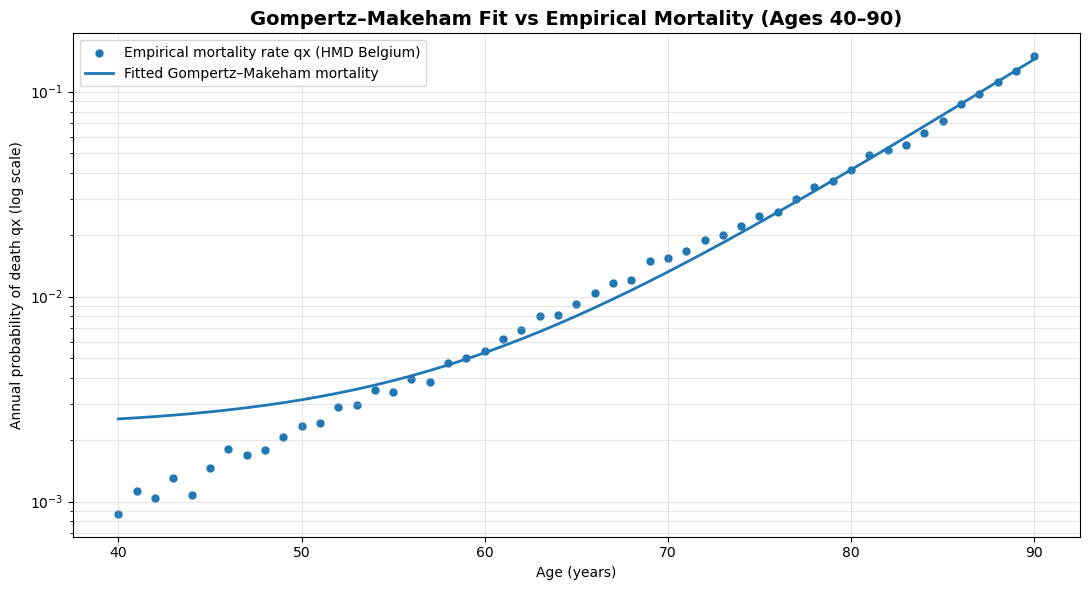

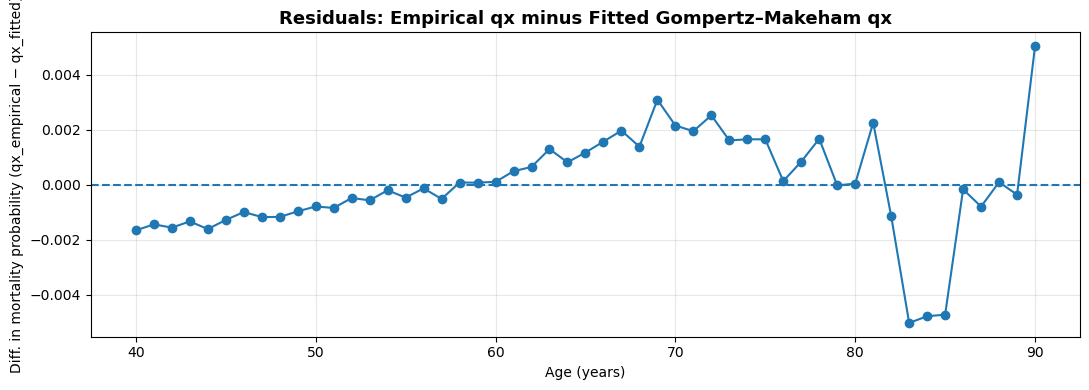

In [12]:
# ============================================================
# Title: Act 2 — Gompertz–Makeham Fit Diagnostics (Full)
# Cell: 10
# Version: 1.1
# Date: 2026-04-27
# Description:
# Evaluate the quality of the Gompertz–Makeham fit:
# - compute fitted values
# - compute residuals
# - compute RMSE
# - produce professional diagnostic plots
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Compute fitted values
# ------------------------------------------------------------

fit_data = fit_data.copy()  # ensure no chained assignment issues

fit_data["qx_fitted"] = gompertz_makeham(
    fit_data["Age"].values,
    A_fit,
    B_fit,
    C_fit
)

# ------------------------------------------------------------
# Residuals and metrics
# ------------------------------------------------------------

fit_data["residual"] = fit_data["qx"] - fit_data["qx_fitted"]

rmse = np.sqrt(np.mean(fit_data["residual"]**2))

print("Fit quality metrics:")
print(f"RMSE (absolute error on qx): {rmse:.6e}")

# ------------------------------------------------------------
# Plot 1 — Empirical vs Fitted (log scale)
# ------------------------------------------------------------

plt.figure(figsize=(11, 6))

plt.scatter(
    fit_data["Age"],
    fit_data["qx"],
    label="Empirical mortality rate qx (HMD Belgium)",
    s=25
)

plt.plot(
    fit_data["Age"],
    fit_data["qx_fitted"],
    linewidth=2,
    label="Fitted Gompertz–Makeham mortality"
)

plt.yscale("log")

plt.title(
    f"Gompertz–Makeham Fit vs Empirical Mortality "
    f"(Ages {FIT_AGE_MIN}–{FIT_AGE_MAX})",
    fontsize=14,
    weight="bold"
)

plt.xlabel("Age (years)")
plt.ylabel("Annual probability of death qx (log scale)")

plt.legend()
plt.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Plot 2 — Residuals (absolute error)
# ------------------------------------------------------------

plt.figure(figsize=(11, 4))

plt.axhline(0, linestyle="--")

plt.plot(
    fit_data["Age"],
    fit_data["residual"],
    marker="o"
)

plt.title(
    "Residuals: Empirical qx minus Fitted Gompertz–Makeham qx",
    fontsize=13,
    weight="bold"
)

plt.xlabel("Age (years)")
plt.ylabel("Diff. in mortality probability (qx_empirical − qx_fitted)")

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

<div style="
    background-color:#f7fbff;
    border-left:6px solid #1565c0;
    padding:16px;
    border-radius:10px;
    font-family:Arial, sans-serif;
">

<h3>Interpretation — Gompertz–Makeham Fit</h3>

<p>
The fitted Gompertz–Makeham model captures the overall exponential increase
in mortality with age and provides a good approximation over the core
age range.
</p>

<p>
Residual analysis reveals:
</p>

<ul>
<li>Systematic deviation at younger ages (below ~50)</li>
<li>Strong fit in the main actuarial range (60–85)</li>
<li>Increased variability at extreme ages</li>
</ul>

<p>
A refinement using a narrower age range (50–90) leads to instability in the
Makeham parameter \(A\), indicating partial identifiability issues between
the model components:
</p>

<p style="font-size:18px;">
\[
\mu(x) = A + B e^{Cx}
\]
</p>

<p>
For this reason, the broader fit (40–90) is retained as the actuarially
more stable specification.
</p>

</div>

<div style="
    background-color:#eef7f1;
    border-left:6px solid #2e7d32;
    padding:18px;
    border-radius:10px;
    font-family:Arial, sans-serif;
">

<h2>Act 3 — Income-Based Longevity Segmentation</h2>

<h3>What we do</h3>
<p>
We introduce socio-economic mortality differentiation by defining three income groups:
low, middle, and high income.
Each group receives a structurally distinct Gompertz–Makeham mortality law.
</p>

<h3>Why it matters</h3>
<p>
Longevity is not uniform across a pension fund. Income, education, profession, and
socio-economic status are often associated with different mortality patterns.
Ignoring this heterogeneity may distort liabilities, especially in pension schemes
where benefit levels are correlated with income.
</p>

<h3>Expected outcome</h3>
<p>
Three mortality curves:
</p>

<p style="font-size:18px;">
\[
\mu_i(x)=A_i+B_i e^{C_i x}
\]
</p>

<p>
where \(i\) represents the income group. These curves will later feed into member-level
cashflow projections and liability calculations.
</p>

<h3>Modeling principle</h3>
<p>
We do not multiply mortality rates directly by arbitrary factors.
Instead, longevity differences are introduced by shifting the underlying
Gompertz–Makeham parameters \(A\), \(B\), and \(C\).
</p>

</div>

<div style="
    background-color:#eef4fb;
    border-left:6px solid #1565c0;
    padding:16px;
    border-radius:10px;
    font-family:Arial, sans-serif;
">

<h3>Act 3 — Cell 12: Defining Income-Based Parameter Shifts</h3>

<h4>What we do</h4>
<p>
We define three income groups and assign each group a structurally modified
Gompertz–Makeham parameter set derived from the baseline fit.
</p>

<h4>Why it matters</h4>
<p>
Longevity differences across socio-economic groups are introduced via parameter shifts,
not direct scaling of mortality rates. This preserves the mathematical structure of the model.
</p>

<h4>Expected outcome</h4>
<p>
Three parameter sets:
</p>

<p style="font-size:18px;">
\[
(A_i, B_i, C_i), \quad i \in \{\text{low, mid, high}\}
\]
</p>

<p>
where mortality is higher for low income and lower for high income groups.
</p>

</div>

In [13]:
# ============================================================
# Title: Act 3 — Income-Based Parameter Shifts
# Cell: 12
# Version: 1.0
# Date: 2026-04-27
# Description:
# Define Gompertz–Makeham parameter sets for three income groups
# based on shifts applied to the baseline fitted parameters.
# ============================================================

# ------------------------------------------------------------
# Baseline parameters (from Act 2)
# ------------------------------------------------------------

A_base = A_fit
B_base = B_fit
C_base = C_fit

print("Baseline parameters:")
print(f"A = {A_base:.8f}, B = {B_base:.8f}, C = {C_base:.6f}")


# ------------------------------------------------------------
# Define parameter shifts (actuarial judgment)
# ------------------------------------------------------------

# Low income → higher mortality
params_low = {
    "A": A_base * 1.20,
    "B": B_base * 1.15,
    "C": C_base * 1.02
}

# Middle income → baseline
params_mid = {
    "A": A_base,
    "B": B_base,
    "C": C_base
}

# High income → lower mortality
params_high = {
    "A": A_base * 0.80,
    "B": B_base * 0.85,
    "C": C_base * 0.98
}


# ------------------------------------------------------------
# Collect in dictionary
# ------------------------------------------------------------

mortality_params = {
    "low": params_low,
    "mid": params_mid,
    "high": params_high
}


# ------------------------------------------------------------
# Display parameters
# ------------------------------------------------------------

for group, p in mortality_params.items():
    print(f"\nGroup: {group}")
    print(f"A = {p['A']:.8f}")
    print(f"B = {p['B']:.8f}")
    print(f"C = {p['C']:.6f}")

Baseline parameters:
A = 0.00229767, B = 0.00000138, C = 0.128168

Group: low
A = 0.00275720
B = 0.00000159
C = 0.130731

Group: mid
A = 0.00229767
B = 0.00000138
C = 0.128168

Group: high
A = 0.00183813
B = 0.00000118
C = 0.125605


<div style="
    background-color:#fff8e1;
    border-left:6px solid #f9a825;
    padding:16px;
    border-radius:10px;
    font-family:Arial, sans-serif;
">

<h3>Act 3 — Cell 14: Hybrid Mortality Construction</h3>

<h4>What we do</h4>
<p>
We construct income-specific mortality curves using a hybrid approach:
empirical HMD mortality at younger ages and Gompertz–Makeham mortality at higher ages.
</p>

<h4>Why it matters</h4>
<p>
The Gompertz–Makeham model does not accurately represent mortality at younger ages.
A hybrid approach ensures realistic mortality levels while preserving parametric structure
where appropriate.
</p>

<h4>Expected outcome</h4>
<p>
A mortality curve that is:
</p>

<ul>
<li>empirically anchored at young ages</li>
<li>smooth and parametric at higher ages</li>
<li>consistent across income groups</li>
</ul>

</div>

In [14]:
# ============================================================
# Title: Act 3 — Hybrid Mortality Curves
# Cell: 14
# Version: 1.0
# Date: 2026-04-27
# Description:
# Construct hybrid mortality curves:
# - HMD data for ages < 50
# - Gompertz–Makeham for ages ≥ 50
# ============================================================

import numpy as np
import pandas as pd

HYBRID_SWITCH_AGE = 50

hybrid = pd.DataFrame({"Age": age_grid})

# Base empirical qx (HMD)
empirical_qx = dict(zip(unisex["Age"], unisex["qx"]))

for group, p in mortality_params.items():

    qx_values = []

    for age in age_grid:

        if age < HYBRID_SWITCH_AGE:
            # empirical anchor
            qx = empirical_qx[age]

        else:
            # parametric model
            qx = gompertz_makeham(age, p["A"], p["B"], p["C"])

        qx_values.append(qx)

    hybrid[f"qx_{group}"] = qx_values

# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

for group in mortality_params:
    col = f"qx_{group}"
    assert hybrid[col].between(0, 1).all()

print("Hybrid mortality curves constructed.")
display(hybrid.head())
display(hybrid.tail())

NameError: name 'age_grid' is not defined

<div style="
    background-color:#eef4fb;
    border-left:6px solid #1565c0;
    padding:16px;
    border-radius:10px;
    font-family:Arial, sans-serif;
">

<h3>Act 3 — Cell 15: Visualisation of Hybrid Mortality Curves</h3>

<h4>What we do</h4>
<p>
We visualize the hybrid mortality curves for the three income groups,
combining empirical HMD data at younger ages and Gompertz–Makeham mortality
at higher ages.
</p>

<h4>Why it matters</h4>
<p>
Visual inspection is essential to validate that:
</p>

<ul>
<li>young-age mortality is realistic (anchored to HMD)</li>
<li>curves diverge appropriately by income</li>
<li>no discontinuity occurs at the switching age</li>
</ul>

<h4>Expected outcome</h4>
<p>
Smooth, realistic mortality curves with clear but moderate separation between
income groups.
</p>

</div>

In [ ]:
# ============================================================
# Title: Act 3 — Hybrid Mortality Curve Visualisation
# Cell: 15
# Version: 1.0
# Date: 2026-04-27
# Description:
# Plot hybrid mortality curves and compare with empirical data.
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

plt.figure(figsize=(11, 6))

# Plot empirical baseline (reference)
plt.scatter(
    unisex["Age"],
    unisex["qx"],
    s=15,
    alpha=0.4,
    label="Empirical HMD mortality (baseline)"
)

# Plot hybrid curves
plt.plot(
    hybrid["Age"],
    hybrid["qx_low"],
    linewidth=2,
    label="Low income"
)

plt.plot(
    hybrid["Age"],
    hybrid["qx_mid"],
    linewidth=2,
    label="Middle income"
)

plt.plot(
    hybrid["Age"],
    hybrid["qx_high"],
    linewidth=2,
    label="High income"
)

# Switch line
plt.axvline(
    x=HYBRID_SWITCH_AGE,
    linestyle="--",
    alpha=0.6,
    label=f"Switch age ({HYBRID_SWITCH_AGE})"
)

plt.yscale("log")

plt.title(
    "Hybrid Income-Specific Mortality Curves (HMD + Gompertz–Makeham)",
    fontsize=14,
    weight="bold"
)

plt.xlabel("Age (years)")
plt.ylabel("Annual probability of death qx (log scale)")

plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))

plt.legend()
plt.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

<div style="
    background-color:#eef7f1;
    border-left:6px solid #2e7d32;
    padding:16px;
    border-radius:10px;
    font-family:Arial, sans-serif;
">

<h3>Act 3 — Smooth Transition Between Empirical and Parametric Mortality</h3>

<p>
We replace the hard switch at age 50 with a smooth transition between
empirical HMD mortality and Gompertz–Makeham mortality.
</p>

<p>
This avoids artificial discontinuities and produces a more realistic mortality curve.
</p>

</div>

In [ ]:
# ============================================================
# Title: Act 3 — Smooth Hybrid Mortality Curves
# Cell: 16
# Version: 1.0
# Date: 2026-04-27
# Description:
# Construct smooth hybrid mortality curves using blending
# between HMD and Gompertz–Makeham.
# ============================================================

import numpy as np
import pandas as pd

BLEND_START = 45
BLEND_END = 55

smooth = pd.DataFrame({"Age": age_grid})

empirical_qx = dict(zip(unisex["Age"], unisex["qx"]))


def blend_weight(age):
    if age <= BLEND_START:
        return 1.0
    elif age >= BLEND_END:
        return 0.0
    else:
        # linear interpolation
        return (BLEND_END - age) / (BLEND_END - BLEND_START)


for group, p in mortality_params.items():

    qx_values = []

    for age in age_grid:

        q_emp = empirical_qx[age]
        q_gm = gompertz_makeham(age, p["A"], p["B"], p["C"])

        w = blend_weight(age)

        qx = w * q_emp + (1 - w) * q_gm

        qx_values.append(qx)

    smooth[f"qx_{group}"] = qx_values

print("Smooth hybrid mortality constructed.")
display(smooth.head())
display(smooth.tail())

In [ ]:
# ============================================================
# Title: Act 3 — Smooth Curve Visualisation
# Cell: 17
# Version: 1.0
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

plt.figure(figsize=(11, 6))

plt.scatter(
    unisex["Age"],
    unisex["qx"],
    s=15,
    alpha=0.4,
    label="Empirical HMD"
)

plt.plot(smooth["Age"], smooth["qx_low"], label="Low income", linewidth=2)
plt.plot(smooth["Age"], smooth["qx_mid"], label="Middle income", linewidth=2)
plt.plot(smooth["Age"], smooth["qx_high"], label="High income", linewidth=2)

plt.axvspan(BLEND_START, BLEND_END, alpha=0.1, label="Transition zone")

plt.yscale("log")

plt.title("Smooth Hybrid Mortality Curves", fontsize=14, weight="bold")
plt.xlabel("Age (years)")
plt.ylabel("Annual probability of death qx (log scale)")

plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))

plt.legend()
plt.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

<div style="
    background-color:#eef7f1;
    border-left:6px solid #2e7d32;
    padding:16px;
    border-radius:10px;
    font-family:Arial, sans-serif;
">

<h3>Act 3 — Cell 18: Anchored Parametric Mortality Curves</h3>

<h4>What we do</h4>
<p>
We replace the blended hybrid curve with an anchored parametric construction.
Below the anchor age, mortality follows empirical HMD data. From the anchor age onward,
each income-specific Gompertz–Makeham curve is rescaled to match the HMD mortality level
at the anchor age.
</p>

<h4>Why it matters</h4>
<p>
This avoids both the unrealistic young-age Makeham level and the visual roughness created
by blending noisy empirical annual mortality rates.
</p>

<h4>Expected outcome</h4>
<p>
A continuous, cleaner, actuarially defensible set of income-specific mortality curves.
</p>

<p style="font-size:18px;">
\[
q_x^{(i)} =
\begin{cases}
q_x^{HMD}, & x < x_0 \\
q_{x_0}^{HMD}\cdot
\dfrac{q_x^{GM,i}}{q_{x_0}^{GM,i}}, & x \ge x_0
\end{cases}
\]
</p>

</div>

In [ ]:
# ============================================================
# Title: Act 3 — Anchored Parametric Mortality Curves
# Cell: 18
# Version: 1.0
# Date: 2026-04-27
# Description:
# Construct income-specific mortality curves by using empirical
# HMD mortality below an anchor age and rescaled Gompertz–
# Makeham mortality from the anchor age onward.
# ============================================================

import numpy as np
import pandas as pd

ANCHOR_AGE = 55

anchored = pd.DataFrame({"Age": age_grid})

empirical_qx = dict(zip(unisex["Age"], unisex["qx"]))
q_anchor_empirical = empirical_qx[ANCHOR_AGE]

for group, p in mortality_params.items():

    qx_values = []

    q_anchor_gm = gompertz_makeham(
        ANCHOR_AGE,
        p["A"],
        p["B"],
        p["C"]
    )

    for age in age_grid:

        if age < ANCHOR_AGE:
            qx = empirical_qx[age]
        else:
            q_gm_age = gompertz_makeham(
                age,
                p["A"],
                p["B"],
                p["C"]
            )

            qx = q_anchor_empirical * q_gm_age / q_anchor_gm

        qx_values.append(qx)

    anchored[f"qx_{group}"] = qx_values

# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

for group in mortality_params:
    col = f"qx_{group}"
    assert anchored[col].between(0, 1).all(), f"{col} outside [0,1]"

assert np.isclose(
    anchored.loc[anchored["Age"] == ANCHOR_AGE, "qx_mid"].iloc[0],
    q_anchor_empirical
), "Middle curve is not anchored correctly."

print("Anchored income-specific mortality curves constructed.")
print(f"Anchor age: {ANCHOR_AGE}")
print(f"HMD qx at anchor age: {q_anchor_empirical:.8f}")

display(anchored.head())
display(anchored[anchored["Age"].between(50, 60)])
display(anchored.tail())

In [ ]:
# ============================================================
# Title: Act 3 — Anchored Mortality Curve Visualisation
# Cell: 19
# Version: 1.0
# Date: 2026-04-27
# Description:
# Visualize anchored income-specific mortality curves and compare
# them with empirical HMD mortality.
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

plt.figure(figsize=(11, 6))

plt.scatter(
    unisex["Age"],
    unisex["qx"],
    s=15,
    alpha=0.35,
    label="Empirical HMD mortality"
)

plt.plot(
    anchored["Age"],
    anchored["qx_low"],
    linewidth=2,
    label="Low income"
)

plt.plot(
    anchored["Age"],
    anchored["qx_mid"],
    linewidth=2,
    label="Middle income"
)

plt.plot(
    anchored["Age"],
    anchored["qx_high"],
    linewidth=2,
    label="High income"
)

plt.axvline(
    ANCHOR_AGE,
    linestyle="--",
    alpha=0.6,
    label=f"Anchor age ({ANCHOR_AGE})"
)

plt.yscale("log")

plt.title(
    "Anchored Income-Specific Mortality Curves",
    fontsize=14,
    weight="bold"
)

plt.xlabel("Age (years)")
plt.ylabel("Annual probability of death qx (log scale)")

plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))

plt.legend()
plt.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

<div style="
    background-color:#f7fbff;
    border-left:6px solid #1565c0;
    padding:16px;
    border-radius:10px;
    font-family:Arial, sans-serif;
">

<h3>Interpretation — Income-Specific Mortality Curves</h3>

<p>
The final segmentation approach uses empirical Belgian HMD mortality up to age 55
and anchored Gompertz–Makeham curves thereafter.
</p>

<p>
This gives a defensible compromise:
</p>

<ul>
<li>young and mid-life mortality remains grounded in observed Belgian data</li>
<li>older-age mortality follows a smooth parametric structure</li>
<li>income-based longevity differences emerge gradually after the anchor age</li>
<li>the curves remain continuous at the anchor point</li>
</ul>

<p>
The income segmentation should be interpreted as a transparent scenario assumption,
not as a calibrated Belgian socio-economic mortality table.
In a production assignment, the parameter shifts would be calibrated to fund experience,
external socio-economic mortality studies, or sponsor-specific underwriting data.
</p>

</div>

<div style="
    background-color:#eef4fb;
    border-left:6px solid #1565c0;
    padding:18px;
    border-radius:10px;
    font-family:Arial, sans-serif;
">

<h3>Act 4 — Cell 20: Pension Fund Population and Salary Simulation</h3>

<h4>What we do</h4>
<p>
We generate a synthetic pension fund population of approximately 10,000 members,
split between active members and retirees.
</p>

<h4>Salary modeling</h4>
<p>
Active members receive salaries generated from a lognormal distribution:
</p>

<p style="font-size:18px;">
\[
Salary \sim \text{LogNormal}(\mu, \sigma)
\]
</p>

<p>
The lognormal distribution is used because salaries are positive and typically
right-skewed: most members earn around a central range, while a smaller number
have substantially higher salaries.
</p>

<h4>Income segmentation</h4>
<p>
Active members are assigned to low, middle, and high income groups based on
salary percentiles.
Retirees are assigned to income groups using the same overall distribution,
representing their historical career income category rather than current salary.
</p>

<h4>Important modeling note</h4>
<p>
Retirees do not have a current salary in the model. Their pensionable salary proxy
is introduced later when annual pension benefits are calculated.
</p>

</div>

In [ ]:
# ============================================================
# Title: Act 4 — Pension Fund Population Simulation (Revised)
# Cell: 20
# Version: 1.1
# Date: 2026-04-27
# Description:
# Generate a synthetic pension fund population with consistent
# income segmentation across actives and retirees.
# ============================================================

import numpy as np
import pandas as pd

np.random.seed(42)

N_MEMBERS = 10_000

# ------------------------------------------------------------
# Age distribution
# ------------------------------------------------------------

n_actives = int(0.6 * N_MEMBERS)
n_retirees = N_MEMBERS - n_actives

ages_actives = np.random.randint(25, 65, size=n_actives)
ages_retirees = np.random.randint(65, 91, size=n_retirees)

ages = np.concatenate([ages_actives, ages_retirees])

status = np.array(["active"] * n_actives + ["retired"] * n_retirees)

# ------------------------------------------------------------
# Salary generation (for actives)
# ------------------------------------------------------------

mu_log = 10.5
sigma_log = 0.5

salary = np.zeros(N_MEMBERS)

salary_actives = np.random.lognormal(mu_log, sigma_log, size=n_actives)
salary[:n_actives] = salary_actives

# ------------------------------------------------------------
# Assign income groups (based on actives)
# ------------------------------------------------------------

percentiles = np.percentile(salary_actives, [33, 66])

income_group = np.empty(N_MEMBERS, dtype=object)

# Actives
for i in range(n_actives):
    if salary[i] <= percentiles[0]:
        income_group[i] = "low"
    elif salary[i] <= percentiles[1]:
        income_group[i] = "mid"
    else:
        income_group[i] = "high"

# Retirees: inherit distribution of actives
# (draw from same proportions)

groups = ["low", "mid", "high"]
probs = [0.33, 0.34, 0.33]

income_group[n_actives:] = np.random.choice(groups, size=n_retirees, p=probs)

# ------------------------------------------------------------
# Assemble DataFrame
# ------------------------------------------------------------

population = pd.DataFrame({
    "Age": ages,
    "Status": status,
    "Salary": salary,
    "IncomeGroup": income_group
})

# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

assert len(population) == N_MEMBERS
assert population["Age"].between(25, 90).all()

print("Population generated (revised).")
print("\nStatus distribution:")
print(population["Status"].value_counts())

print("\nIncome distribution:")
print(population["IncomeGroup"].value_counts())

display(population.head())

<div style="
    background-color:#eef4fb;
    border-left:6px solid #1565c0;
    padding:16px;
    border-radius:10px;
    font-family:Arial, sans-serif;
">

<h3>Act 4 — Cell 21: Service Years and Pension Benefits</h3>

<h4>What we do</h4>
<p>
We assign service years and calculate annual pension benefits for active and retired members.
</p>

<h4>Why it matters</h4>
<p>
Pension liabilities are driven by benefit amounts. Mortality determines how long benefits are paid;
the benefit formula determines how much is paid.
</p>

<h4>Expected outcome</h4>
<p>
A member-level pension amount based on:
</p>

<p style="font-size:18px;">
\[
\text{Annual Pension}
=
\text{Salary} \times \text{Service Years} \times \text{Accrual Rate}
\]
</p>

</div>

In [ ]:
# ============================================================
# Title: Act 4 — Service Years (Refined)
# Cell: 21 (Version 1.1)
# Description:
# Introduce variability in entry age to avoid deterministic careers.
# ============================================================

population = population.copy()

ACCRUAL_RATE = 0.0175
RETIREMENT_AGE = 65

# ------------------------------------------------------------
# Entry age (random between 22 and 30)
# ------------------------------------------------------------

population["EntryAge"] = np.random.randint(22, 31, size=len(population))

# ------------------------------------------------------------
# Service years
# ------------------------------------------------------------

population["ServiceYears"] = (
    population["Age"] - population["EntryAge"]
).clip(lower=0)

# retirees: ensure full careers
retired_mask = population["Status"] == "retired"

population.loc[retired_mask, "ServiceYears"] = np.random.randint(
    30,
    41,
    size=retired_mask.sum()
)

# ------------------------------------------------------------
# Final salary proxy
# ------------------------------------------------------------

retiree_salary_proxy = {
    "low": 35_000,
    "mid": 55_000,
    "high": 85_000
}

population["FinalSalaryProxy"] = population["Salary"]

for group, amount in retiree_salary_proxy.items():
    mask = retired_mask & (population["IncomeGroup"] == group)
    population.loc[mask, "FinalSalaryProxy"] = amount

# ------------------------------------------------------------
# Annual pension
# ------------------------------------------------------------

population["AnnualPension"] = (
    population["FinalSalaryProxy"]
    * population["ServiceYears"]
    * ACCRUAL_RATE
)

# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

assert population["ServiceYears"].ge(0).all()
assert population["AnnualPension"].ge(0).all()

print("Refined service years and pensions computed.")

display(population.head())

<div style="
    background-color:#eef7f1;
    border-left:6px solid #2e7d32;
    padding:18px;
    border-radius:10px;
    font-family:Arial, sans-serif;
">

<h2>Act 5 — Cohort Cashflow Projection</h2>

<h3>What we do</h3>
<p>
We project future pension payments by combining individual pension amounts
with survival probabilities and retirement timing.
</p>

<h3>Core formula</h3>

<p style="font-size:18px;">
\[
CF_t = \sum_{i=1}^{N} P_i \cdot \Pr(\text{member } i \text{ is alive at time } t)
\cdot \Pr(\text{member } i \text{ is retired at time } t)
\]
</p>

<h3>Definitions</h3>

<ul>
<li><b>\(CF_t\)</b>: expected total pension cashflow at time \(t\)</li>
<li><b>\(i\)</b>: index of a member in the pension fund</li>
<li><b>\(N\)</b>: total number of members</li>
<li><b>\(P_i\)</b>: annual pension benefit of member \(i\)</li>
<li><b>\(t\)</b>: number of years in the future</li>
<li><b>\(\Pr(\text{alive at } t)\)</b>: probability that the member survives to time \(t\)</li>
<li><b>\(\Pr(\text{retired at } t)\)</b>: probability that the member has retired by time \(t\)</li>
</ul>

<h3>Why it matters</h3>
<p>
This formulation explicitly separates:
</p>

<ul>
<li>mortality risk (survival probabilities)</li>
<li>retirement dynamics (transition from active to retired)</li>
</ul>

<p>
Both effects are essential for realistic pension projections.
</p>

</div>

In [ ]:
# ============================================================
# Title: Act 5 — Stochastic Retirement Ages
# Cell: 22
# Version: 1.0
# Date: 2026-04-27
# Description:
# Assign stochastic retirement ages to active members.
# ============================================================

import numpy as np

population = population.copy()

# ------------------------------------------------------------
# Retirement age distribution
# ------------------------------------------------------------

RET_MEAN = 65
RET_STD = 2

retirement_age = np.random.normal(RET_MEAN, RET_STD, size=len(population))

# clip to realistic bounds
retirement_age = np.clip(retirement_age, 60, 70)

# retirees already retired → retirement age <= current age
retired_mask = population["Status"] == "retired"
retirement_age[retired_mask] = population.loc[retired_mask, "Age"]

population["RetirementAge"] = retirement_age.astype(int)

# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

assert (population["RetirementAge"] >= 60).all()
assert (population["RetirementAge"] <= 90).all()

print("Stochastic retirement ages assigned.")
display(population.head())

<div style="
    background-color:#eef4fb;
    border-left:6px solid #1565c0;
    padding:16px;
    border-radius:10px;
    font-family:Arial, sans-serif;
">

<h3>Act 5 — Retirement-Adjusted Cashflow Projection</h3>

<p>
Pension payments are now conditioned on both survival and retirement status.
</p>

<p style="font-size:18px;">
\[
CF_t = \sum_i P_i \cdot \mathbf{1}_{\{age_i + t \ge R_i\}} \cdot S_i(t)
\]
</p>

<ul>
<li>\(P_i\): annual pension</li>
<li>\(R_i\): retirement age</li>
<li>\(S_i(t)\): survival probability</li>
<li>\(\mathbf{1}\): indicator (1 if retired, 0 otherwise)</li>
</ul>

</div>

In [ ]:
# ============================================================
# Title: Act 5 — Cashflow Projection with Retirement Dynamics
# Cell: 23
# Version: 2.0
# Date: 2026-04-27
# Description:
# Compute expected pension cashflows with retirement timing
# and survival probabilities.
# ============================================================

MAX_YEARS = 60

cashflows = []

for t in range(MAX_YEARS):

    total_cf = 0.0

    for _, row in population.iterrows():

        age = row["Age"]
        pension = row["AnnualPension"]
        ret_age = row["RetirementAge"]

        future_age = age + t

        # retirement condition
        if future_age < ret_age:
            continue  # no pension yet

        # survival probability
        prob_alive = survival_prob(age, t)

        total_cf += pension * prob_alive

    cashflows.append(total_cf)

cashflows = np.array(cashflows)

print("Cashflow projection with retirement completed.")

for t in range(10):
    print(f"Year {t}: {cashflows[t]:,.0f}")

In [ ]:
# ============================================================
# Title: Act 5 — Cashflow Visualisation (Retirement Adjusted)
# Cell: 24
# Version: 2.0
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(11, 6))

plt.plot(cashflows, linewidth=2)

plt.title("Projected Pension Cashflows (with Retirement Dynamics)", fontsize=14, weight="bold")
plt.xlabel("Years in the future")
plt.ylabel("Annual expected pension payments")

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

<div style="
    background-color:#eef7f1;
    border-left:6px solid #2e7d32;
    padding:16px;
    border-radius:10px;
    font-family:Arial, sans-serif;
">

<h3>Act 5 — Cell 25: Projected Pension at Retirement</h3>

<h4>What we do</h4>
<p>
We project active members' salaries and service years to their retirement age,
then compute their expected pension at retirement.
</p>

<h4>Why it matters</h4>
<p>
A pension fund liability is not based only on benefits accrued today.
For active members, future salary growth and future service can materially increase
the pension payable at retirement.
</p>

<p style="font-size:18px;">
\[
P_i^{ret}
=
Salary_i \cdot (1+g)^{R_i-age_i}
\cdot Service_i^{ret}
\cdot AccrualRate
\]
</p>

<ul>
<li>\(P_i^{ret}\): projected annual pension at retirement</li>
<li>\(Salary_i\): current salary</li>
<li>\(g\): annual salary growth assumption</li>
<li>\(R_i\): retirement age</li>
<li>\(age_i\): current age</li>
<li>\(Service_i^{ret}\): projected service years at retirement</li>
</ul>

</div>

In [ ]:
# ============================================================
# Title: Act 5 — Projected Pension at Retirement
# Cell: 25
# Version: 1.1
# Date: 2026-04-27
# Description:
# Project active members' salaries and service to retirement,
# and compute projected pension at retirement with correct dtypes.
# ============================================================

import numpy as np
import pandas as pd

population = population.copy()

SALARY_GROWTH = 0.025

active_mask = population["Status"] == "active"
retired_mask = population["Status"] == "retired"

# ------------------------------------------------------------
# Years to retirement
# ------------------------------------------------------------

population["YearsToRetirement"] = (
    population["RetirementAge"] - population["Age"]
).clip(lower=0).astype(int)

# ------------------------------------------------------------
# Projected salary at retirement
# ------------------------------------------------------------

population["ProjectedSalaryAtRetirement"] = population["FinalSalaryProxy"].astype(float)

population.loc[active_mask, "ProjectedSalaryAtRetirement"] = (
    population.loc[active_mask, "Salary"]
    * (1 + SALARY_GROWTH) ** population.loc[active_mask, "YearsToRetirement"]
)

# ------------------------------------------------------------
# Projected service at retirement (force integer dtype)
# ------------------------------------------------------------

population["ProjectedServiceAtRetirement"] = population["ServiceYears"].astype(int)

population.loc[active_mask, "ProjectedServiceAtRetirement"] = (
    population.loc[active_mask, "ServiceYears"]
    + population.loc[active_mask, "YearsToRetirement"]
).astype(int)

# ------------------------------------------------------------
# Projected pension payable once retired
# ------------------------------------------------------------

population["ProjectedAnnualPension"] = population["AnnualPension"].astype(float)

population.loc[active_mask, "ProjectedAnnualPension"] = (
    population.loc[active_mask, "ProjectedSalaryAtRetirement"]
    * population.loc[active_mask, "ProjectedServiceAtRetirement"]
    * ACCRUAL_RATE
)

# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

assert population["ProjectedAnnualPension"].ge(0).all()
assert (population["ProjectedServiceAtRetirement"] >= population["ServiceYears"]).all()
assert population.loc[retired_mask, "ProjectedAnnualPension"].equals(
    population.loc[retired_mask, "AnnualPension"]
)

print("Projected pensions at retirement computed (clean).")
print(f"Salary growth assumption: {SALARY_GROWTH:.2%}")

display(population.head())

summary_projected = (
    population
    .groupby(["Status", "IncomeGroup"])
    .agg(
        Members=("Age", "count"),
        AvgAge=("Age", "mean"),
        AvgYearsToRetirement=("YearsToRetirement", "mean"),
        AvgCurrentPension=("AnnualPension", "mean"),
        AvgProjectedPension=("ProjectedAnnualPension", "mean")
    )
    .reset_index()
)

display(summary_projected)

<div style="
    background-color:#eef4fb;
    border-left:6px solid #1565c0;
    padding:16px;
    border-radius:10px;
    font-family:Arial, sans-serif;
">

<h3>Act 5 — Cell 26: Cashflows with Projected Active Benefits</h3>

<h4>What we do</h4>
<p>
We rerun the pension cashflow projection using projected pensions at retirement for active members.
Retirees continue to receive their current pension.
</p>

<h4>Why it matters</h4>
<p>
This reflects the economic reality of an ongoing pension fund: active members continue to accrue service
and experience salary growth before retirement.
</p>

<p style="font-size:18px;">
\[
CF_t =
\sum_i
P_i^{ret}
\cdot
\mathbf{1}_{\{age_i+t \ge R_i\}}
\cdot
S_i(t)
\]
</p>

</div>

In [ ]:
# ============================================================
# Title: Act 5 — Cashflow Projection with Projected Benefits
# Cell: 26
# Version: 1.0
# Date: 2026-04-27
# Description:
# Compute expected pension cashflows using projected pensions
# for active members and current pensions for retirees.
# ============================================================

import numpy as np

MAX_YEARS = 60

cashflows = []

for t in range(MAX_YEARS):

    total_cf = 0.0

    for _, row in population.iterrows():

        age = int(row["Age"])
        future_age = age + t

        if future_age > AGE_MAX:
            continue

        ret_age = int(row["RetirementAge"])

        if future_age < ret_age:
            continue

        pension = float(row["ProjectedAnnualPension"])
        prob_alive = survival_prob(age, t)

        total_cf += pension * prob_alive

    cashflows.append(total_cf)

cashflows = np.array(cashflows, dtype=float)

print("Cashflow projection with projected active benefits completed.")

for t in range(15):
    print(f"Year {t:02d}: {cashflows[t]:,.0f}")

<div style="
    background-color:#f7fbff;
    border-left:6px solid #1565c0;
    padding:18px;
    border-radius:10px;
    font-family:Arial, sans-serif;
">

<h3>Interpretation — Projected Pension Cashflows</h3>

<p>
The projected cashflow profile exhibits a <b>delayed hump shape</b>, which is
characteristic of a <b>mature defined benefit pension fund</b>.
</p>

<h4>Phase 1 — Initial Decline</h4>
<p>
In the early years, cashflows decrease. This reflects the fact that the fund already
contains a significant proportion of retirees who are immediately in payment.
As these pensioners age, mortality reduces the total number of beneficiaries,
leading to a decline in aggregate pension payments.
</p>

<h4>Phase 2 — Build-up</h4>
<p>
From approximately year 15 onwards, cashflows begin to increase. This is driven by
the retirement of active members, who enter the pension payment phase.
These new retirees often have higher projected pensions due to salary growth
and additional service accrual, which outweighs the ongoing mortality of existing retirees.
</p>

<h4>Phase 3 — Run-off</h4>
<p>
After reaching a peak (around year 40), cashflows decline again. At this stage,
most members are retired, and mortality becomes the dominant force.
The fund progressively runs off as the population ages.
</p>

<h4>Key Insight</h4>
<p>
The shape of the curve is not purely a demographic artifact, but the result of the
interaction between:
</p>

<ul>
<li>the current age structure of the population</li>
<li>retirement timing</li>
<li>mortality dynamics</li>
<li>benefit levels and salary growth</li>
</ul>

<p>
In particular, the delayed hump reflects the <b>maturity of the fund</b>,
where a large share of liabilities is already in payment at the valuation date.
</p>

</div>

In [ ]:
# ============================================================
# Title: Act 5 — Cashflow Decomposition with Income-Specific Mortality
# Cell: 28
# Version: 2.0
# Date: 2026-04-28
# Description:
# Project pension cashflows using income-specific mortality curves.
# Members are mapped to low / mid / high mortality according to
# their IncomeGroup. The resulting cashflows are decomposed into
# current retirees and current actives.
# ============================================================

import numpy as np

MAX_YEARS = 60

# ------------------------------------------------------------
# Build income-specific qx lookup tables from anchored curves
# ------------------------------------------------------------

qx_by_income = {
    "low": dict(zip(anchored["Age"], anchored["qx_low"])),
    "mid": dict(zip(anchored["Age"], anchored["qx_mid"])),
    "high": dict(zip(anchored["Age"], anchored["qx_high"])),
}


# ------------------------------------------------------------
# Income-specific survival function
# ------------------------------------------------------------

def survival_prob_income(age_now, t, income_group):
    """
    Probability that a member survives t years from current age,
    using the mortality curve corresponding to the member's income group.
    """

    age_now = int(age_now)
    t = int(t)

    if t == 0:
        return 1.0

    future_age = age_now + t

    if future_age > AGE_MAX:
        return 0.0

    if income_group not in qx_by_income:
        raise ValueError(f"Unknown income group: {income_group}")

    qx_lookup = qx_by_income[income_group]

    survival_probability = 1.0

    for age in range(age_now, future_age):
        survival_probability *= (1.0 - qx_lookup[age])

    return survival_probability


# ------------------------------------------------------------
# Project and decompose cashflows
# ------------------------------------------------------------

cashflows_total = []
cashflows_retired = []
cashflows_active = []

for t in range(MAX_YEARS):

    total_cf = 0.0
    retired_cf = 0.0
    active_cf = 0.0

    for _, row in population.iterrows():

        age = int(row["Age"])
        future_age = age + t

        if future_age > AGE_MAX:
            continue

        ret_age = int(row["RetirementAge"])

        if future_age < ret_age:
            continue

        income_group = row["IncomeGroup"]
        pension = float(row["ProjectedAnnualPension"])

        prob_alive = survival_prob_income(age, t, income_group)

        cf = pension * prob_alive

        total_cf += cf

        if row["Status"] == "retired":
            retired_cf += cf
        else:
            active_cf += cf

    cashflows_total.append(total_cf)
    cashflows_retired.append(retired_cf)
    cashflows_active.append(active_cf)

cashflows_total = np.array(cashflows_total, dtype=float)
cashflows_retired = np.array(cashflows_retired, dtype=float)
cashflows_active = np.array(cashflows_active, dtype=float)

# Keep alias for earlier downstream cells
cashflows = cashflows_total.copy()


# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

cashflow_reconciliation_error = np.max(
    np.abs(cashflows_total - (cashflows_retired + cashflows_active))
)

assert cashflow_reconciliation_error < 1e-5, (
    "Cashflow decomposition failed: total != retirees + actives."
)

print("Income-specific cashflow projection completed.")
print(f"Max reconciliation error: {cashflow_reconciliation_error:.2e}")

for t in range(15):
    print(f"Year {t:02d}: {cashflows_total[t]:,.0f}")

print("\nPeak total cashflow:")
print(f"Year {int(np.argmax(cashflows_total))}: {np.max(cashflows_total):,.0f}")

In [ ]:
# ============================================================
# Title: Act 5 — Cashflow Decomposition (Explicit)
# Cell: 29
# Version: 1.1
# Description:
# Explicit visualization showing total as sum of components.
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

years = np.arange(MAX_YEARS)

plt.figure(figsize=(11, 6))

# components
plt.plot(years, cashflows_retired, linewidth=2.5, label="Current retirees", color="tab:blue")
plt.plot(years, cashflows_active, linewidth=2.5, label="Current actives", color="tab:orange")

# total (explicitly thicker)
plt.plot(years, cashflows_total, linewidth=3.5, linestyle="--", color="black", label="Total (sum)")

plt.title(
    "Cashflow Decomposition — Total = Retirees + Actives",
    fontsize=14,
    weight="bold"
)

plt.xlabel("Years in the future")
plt.ylabel("Annual expected pension payments")

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Numerical check (very important)
# ------------------------------------------------------------

max_diff = np.max(np.abs(cashflows_total - (cashflows_retired + cashflows_active)))

print(f"Max numerical difference (should be ~0): {max_diff:.6f}")

<div style="
    background-color:#eef7f1;
    border-left:6px solid #2e7d32;
    padding:18px;
    border-radius:10px;
    font-family:Arial, sans-serif;
">

<h2>Act 6 — Liability Valuation: Best Estimate Liability</h2>

<h3>What we do</h3>
<p>
We convert projected future benefit cashflows into a present value using a discount rate.
This gives the fund's best estimate liability.
</p>

<h3>Why it matters</h3>
<p>
The cashflow projection tells us the future benefit needs of the fund.
The present value tells us how large those future obligations are in today's money.
</p>

<h3>Core formula</h3>

<p style="font-size:18px;">
\[
BEL = \sum_{t=0}^{T} \frac{CF_t}{(1+r)^t}
\]
</p>

<h3>Definitions</h3>

<ul>
<li><b>\(BEL\)</b>: Best Estimate Liability</li>
<li><b>\(CF_t\)</b>: expected pension benefit cashflow in year \(t\)</li>
<li><b>\(r\)</b>: annual discount rate</li>
<li><b>\(T\)</b>: projection horizon</li>
</ul>

</div>

In [ ]:
# ============================================================
# Title: Act 6 — Best Estimate Liability
# Cell: 30
# Version: 1.0
# Date: 2026-04-27
# Description:
# Discount projected pension benefit cashflows to obtain the
# Best Estimate Liability of the pension fund.
# ============================================================

import numpy as np
import pandas as pd

DISCOUNT_RATE = 0.02

years = np.arange(len(cashflows_total))

discount_factors = 1 / (1 + DISCOUNT_RATE) ** years
present_values = cashflows_total * discount_factors

BEL = present_values.sum()

bel_table = pd.DataFrame({
    "Year": years,
    "ExpectedCashflow": cashflows_total,
    "DiscountFactor": discount_factors,
    "PresentValue": present_values
})

print("Best Estimate Liability computed.")
print(f"Discount rate: {DISCOUNT_RATE:.2%}")
print(f"BEL: {BEL:,.0f}")

display(bel_table.head(10))
display(bel_table.tail(10))

<div style="
    background-color:#f7fbff;
    border-left:6px solid #1565c0;
    padding:18px;
    border-radius:10px;
    font-family:Arial, sans-serif;
">

<h3>Interpretation — Best Estimate Liability (BEL)</h3>

<p>
The Best Estimate Liability represents the present value of all future pension
benefit payments, discounted at the assumed interest rate.
</p>

<h4>Result</h4>

<p style="font-size:20px;">
\[
BEL \approx 4.33 \text{ billion}
\]
</p>

<h4>Meaning</h4>

<p>
This amount can be interpreted as the capital that would be required today,
under the assumed discount rate of 2%, to exactly finance all future pension
payments of the fund.
</p>

<h4>Key Drivers</h4>

<ul>
<li>population structure (actives vs retirees)</li>
<li>mortality assumptions</li>
<li>retirement timing</li>
<li>salary growth and benefit accrual</li>
<li>discount rate</li>
</ul>

<h4>Important Insight</h4>

<p>
The liability is not simply the sum of future payments, but a discounted value.
Early cashflows contribute more to the liability than distant cashflows.
</p>

</div>

<div style="
    background-color:#eef7f1;
    border-left:6px solid #2e7d32;
    padding:18px;
    border-radius:10px;
    font-family:Arial, sans-serif;
">

<h2>Act 7 — Funding Need and Required Contributions</h2>

<h3>What we do</h3>
<p>
We compare the fund's Best Estimate Liability with available assets and future contributions.
This turns the liability model into a funding question.
</p>

<h3>Why it matters</h3>
<p>
A pension fund does not only need to know its future benefit payments.
It must also determine whether existing assets and future contributions are sufficient
to finance those payments.
</p>

<h3>Core balance equation</h3>

<p style="font-size:18px;">
\[
Assets_0 + PV(Contributions) = BEL
\]
</p>

<h3>Definitions</h3>

<ul>
<li><b>\(Assets_0\)</b>: current market value of pension fund assets</li>
<li><b>\(PV(Contributions)\)</b>: present value of future contributions from active members</li>
<li><b>\(BEL\)</b>: Best Estimate Liability</li>
</ul>

</div>

In [ ]:
# ============================================================
# Title: Act 7 — Funding Gap
# Cell: 31
# Version: 1.0
# Date: 2026-04-27
# Description:
# Compare current assets with the Best Estimate Liability and
# compute the funding gap before future contributions.
# ============================================================

# ------------------------------------------------------------
# Assumed current asset value
# ------------------------------------------------------------

ASSETS_0 = 3_750_000_000  # EUR

# ------------------------------------------------------------
# Funding position
# ------------------------------------------------------------

funding_gap = BEL - ASSETS_0
funding_ratio = ASSETS_0 / BEL

print("Funding position before future contributions:")
print(f"Assets today      : {ASSETS_0:,.0f}")
print(f"BEL               : {BEL:,.0f}")
print(f"Funding gap       : {funding_gap:,.0f}")
print(f"Funding ratio     : {funding_ratio:.2%}")

<div style="
    background-color:#eef4fb;
    border-left:6px solid #1565c0;
    padding:18px;
    border-radius:10px;
    font-family:Arial, sans-serif;
">

<h3>Act 7 — Survival-Weighted Present Value of Future Salaries</h3>

<h4>What we do</h4>
<p>
We compute the present value of future salary contributions from active members,
allowing for the fact that some active members may die before reaching retirement.
</p>

<h4>Why it matters</h4>
<p>
The active contribution base is not fixed. In a closed fund, the number of contributing
members decreases over time due to mortality and retirement.
Therefore, future salaries must be weighted by the probability that the member is still
alive and active at each future time.
</p>

<h4>Core formula</h4>

<p style="font-size:18px;">
\[
PV(\text{Salaries}) =
\sum_i \sum_{t=0}^{R_i-age_i-1}
Salary_{i,t}
\cdot S_i(t)
\cdot v^t
\]
</p>

<h4>Definitions</h4>

<ul>
<li><b>\(i\)</b>: active member index</li>
<li><b>\(t\)</b>: year in the future</li>
<li><b>\(R_i\)</b>: retirement age of member \(i\)</li>
<li><b>\(age_i\)</b>: current age of member \(i\)</li>
<li><b>\(Salary_{i,t}\)</b>: projected salary of member \(i\) at time \(t\)</li>
<li><b>\(S_i(t)\)</b>: probability that member \(i\) survives to time \(t\)</li>
<li><b>\(v^t = (1+r)^{-t}\)</b>: discount factor</li>
</ul>
 
</div>

In [ ]:
# ============================================================
# Title: Act 7 — Survival-Weighted PV of Future Salaries
# Cell: 32
# Version: 3.0
# Date: 2026-04-28
# Description:
# Compute the present value of future salaries for active members,
# weighted by income-specific survival probabilities and stopping
# at retirement.
# ============================================================

PV_salary = 0.0

for _, row in population.iterrows():

    if row["Status"] != "active":
        continue

    age = int(row["Age"])
    salary = float(row["Salary"])
    ret_age = int(row["RetirementAge"])
    income_group = row["IncomeGroup"]

    years_to_ret = max(ret_age - age, 0)

    for t in range(years_to_ret):

        future_age = age + t

        if future_age > AGE_MAX:
            continue

        future_salary = salary * (1 + SALARY_GROWTH) ** t
        prob_alive = survival_prob_income(age, t, income_group)
        discount = 1 / (1 + DISCOUNT_RATE) ** t

        PV_salary += future_salary * prob_alive * discount

print("Survival-weighted PV of future salaries computed.")
print("Mortality basis: income-specific anchored mortality curves")
print(f"PV of future salaries: {PV_salary:,.0f}")

In [ ]:
# ============================================================
# Title: Act 7 — Required Contribution Rate (Survival-Weighted)
# Cell: 33
# Version: 2.0
# Date: 2026-04-27
# Description:
# Compute the contribution rate required to close the funding gap
# using the survival-weighted salary contribution base.
# ============================================================

required_alpha = funding_gap / PV_salary

print("Required contribution rate using survival-weighted salaries:")
print(f"{required_alpha:.2%}")

<div style="
    background-color:#eef7f1;
    border-left:6px solid #2e7d32;
    padding:18px;
    border-radius:10px;
    font-family:Arial, sans-serif;
">

<h2>Act 8 — Discount Rate Sensitivity</h2>

<h3>What we do</h3>
<p>
We test how sensitive the Best Estimate Liability and required contribution rate are
to the discount rate assumption.
</p>

<h3>Why it matters</h3>
<p>
The discount rate is one of the strongest economic assumptions in pension valuation.
A lower discount rate increases the present value of future pension payments,
while a higher discount rate reduces it.
</p>

<h3>Core formula</h3>

<p style="font-size:18px;">
\[
BEL(r) = \sum_{t=0}^{T} \frac{CF_t}{(1+r)^t}
\]
</p>

<h3>Interpretation</h3>
<p>
For each tested discount rate, we recompute:
</p>

<ul>
<li>Best Estimate Liability</li>
<li>Funding gap</li>
<li>Present value of future salaries</li>
<li>Required contribution rate</li>
</ul>

</div>

In [ ]:
# ============================================================
# Title: Act 8 — Discount Rate Sensitivity Table
# Cell: 34
# Version: 1.0
# Date: 2026-04-27
# Description:
# Compute BEL, funding gap, survival-weighted PV salaries,
# and required contribution rate under alternative discount rates.
# ============================================================

import numpy as np
import pandas as pd

discount_rates = [0.010, 0.015, 0.020, 0.025, 0.030]

sensitivity_rows = []

years = np.arange(len(cashflows_total))

for r in discount_rates:

    # BEL under discount rate r
    discount_factors = 1 / (1 + r) ** years
    bel_r = np.sum(cashflows_total * discount_factors)

    # Funding gap under discount rate r
    funding_gap_r = bel_r - ASSETS_0

    # Survival-weighted PV of active salaries under discount rate r
    pv_salary_r = 0.0

    for _, row in population.iterrows():

        if row["Status"] != "active":
            continue

        age = int(row["Age"])
        salary = float(row["Salary"])
        ret_age = int(row["RetirementAge"])

        years_to_ret = max(ret_age - age, 0)

        for t in range(years_to_ret):

            future_age = age + t

            if future_age > AGE_MAX:
                continue

            future_salary = salary * (1 + SALARY_GROWTH) ** t
            prob_alive = survival_prob(age, t)
            discount = 1 / (1 + r) ** t

            pv_salary_r += future_salary * prob_alive * discount

    required_alpha_r = funding_gap_r / pv_salary_r

    sensitivity_rows.append({
        "DiscountRate": r,
        "BEL": bel_r,
        "FundingGap": funding_gap_r,
        "PVFutureSalaries": pv_salary_r,
        "RequiredContributionRate": required_alpha_r
    })

discount_sensitivity = pd.DataFrame(sensitivity_rows)

display(
    discount_sensitivity.style.format({
        "DiscountRate": "{:.2%}",
        "BEL": "{:,.0f}",
        "FundingGap": "{:,.0f}",
        "PVFutureSalaries": "{:,.0f}",
        "RequiredContributionRate": "{:.2%}"
    })
)

<div style="
  background-color:#FAFAFA;
  border:1px solid #C8B89A;
  border-left:6px solid #1565C0;
  padding:28px 36px;
  border-radius:6px;
  margin:24px 0;
  font-family:'Georgia', serif;
  font-size:14.5px;
  line-height:1.8;
  color:#1a1612;
">

<h1 style="margin-top:0; color:#0D47A1; font-size:1.35rem; border-bottom:1.5px solid #C8B89A; padding-bottom:12px;">
  Act 9 &mdash; Stochastic Liability Distribution via FFT Convolution
</h1>

<h2 style="color:#1565C0; font-size:1.05rem; margin-top:20px;">Motivation</h2>

<p>
The Best Estimate Liability computed in Act 6 is a <strong>point estimate</strong>
&mdash; the expected present value of future benefit payments. It answers the
question <em>how much do we owe on average?</em> but not <em>how bad could it
get?</em> A stochastic capital model answers the second question by computing
the full <strong>distribution</strong> of aggregate pension liability, from which
VaR and TVaR of the funding gap are derived. This is the framework required under
IORP&nbsp;II for internal risk models.
</p>

<h2 style="color:#1565C0; font-size:1.05rem; margin-top:24px;">The Stochastic Structure</h2>

<p>
At each future year $t$, the number of surviving members $N_t$ is a random
variable. For a large closed fund with $n$ members, each surviving year $t$
independently with probability $p_t$:
</p>

$$N_t \sim \mathrm{Binomial}(n,\, p_t)$$

<p>
For large $n$ and small $p_t$, this is well approximated by:
</p>

$$N_t \;\approx\; \mathrm{Poisson}(\lambda_t), \qquad \lambda_t = n \cdot p_t$$

<p>
Each survivor $i$ receives a pension payment $X_{it}$. The aggregate benefit
payment in year $t$ is:
</p>

$$S_t = \sum_{i=1}^{N_t} X_{it}$$

<p>
This is a <strong>compound Poisson aggregate</strong> &mdash; identical in
structure to the motor insurance aggregate model. Individual payments $X_{it}$
follow a lognormal distribution (since salaries are lognormal and
pension $= \alpha \cdot \text{salary} \cdot \text{service}$):
</p>

$$X_{it} \sim \mathrm{LogNormal}(\mu_t,\, \sigma_t)$$

<h2 style="color:#1565C0; font-size:1.05rem; margin-top:24px;">Discounting</h2>

<p>
Future payments are discounted at rate $r$. The present value of aggregate
payments in year $t$ is:
</p>

$$S_t' = \frac{S_t}{(1+r)^t}$$

<p>
Discounting scales the severity distribution: if $X_{it} \sim
\mathrm{LogNormal}(\mu_t, \sigma_t)$, then the discounted payment
$X_{it}' = X_{it}/(1+r)^t$ has mean:
</p>

$$\mu_t' = \frac{\mu_t}{(1+r)^t}$$

<p>with the same CV, since discounting is a linear scaling.</p>

<h2 style="color:#1565C0; font-size:1.05rem; margin-top:24px;">Total Liability</h2>

<p>
The total pension liability is the sum of discounted annual aggregates over
the projection horizon $T$:
</p>

$$L = \sum_{t=1}^{T} S_t'$$

<p>
Since each $S_t'$ is a compound Poisson aggregate and the years are
<strong>independent</strong>, $L$ is itself compound Poisson by the
closure property:
</p>

$$L \sim \mathrm{CompoundPoisson}\!\left(\sum_t \lambda_t,\; F^*\right)$$

<p>
where $F^*$ is the mixture of discounted severity distributions across years.
This means the FFT convolution applies directly to $L$ &mdash;
no simulation required.
</p>

<h2 style="color:#1565C0; font-size:1.05rem; margin-top:24px;">The DecL Specification</h2>

<p>
The <code>aggregate</code> package accepts vector parameters. The full
multi-year aggregate is specified in a single DecL string:
</p>

<div style="
  background:#F3F4F6;
  border-left:3px solid #C8B89A;
  padding:12px 18px;
  font-family:'JetBrains Mono', monospace;
  font-size:12.5px;
  margin:16px 0;
  color:#1a1612;
">
agg TotalLiability [&lambda;<sub>1</sub> &lambda;<sub>2</sub> &hellip; &lambda;<sub>T</sub>] claims<br>
&nbsp;&nbsp;sev lognorm [&mu;<sub>1</sub>' &mu;<sub>2</sub>' &hellip; &mu;<sub>T</sub>']<br>
&nbsp;&nbsp;cv [CV<sub>1</sub> CV<sub>2</sub> &hellip; CV<sub>T</sub>] poisson
</div>

<p>
where $\lambda_t = n \cdot p_t$ is the expected number of survivors in year $t$
and $\mu_t' = \mu / (1+r)^t$ is the discounted mean pension payment.
</p>

<h2 style="color:#1565C0; font-size:1.05rem; margin-top:24px;">Output</h2>

<p>
The result is the full distribution of aggregate pension liability $L$, from
which the following capital metrics are derived:
</p>

<table style="border-collapse:collapse; width:100%; font-size:13.5px; margin:16px 0;">
<thead>
<tr style="background:#0D47A1; color:white;">
  <th style="padding:8px 14px; text-align:left;">Metric</th>
  <th style="padding:8px 14px; text-align:left;">Definition</th>
  <th style="padding:8px 14px; text-align:left;">Interpretation</th>
</tr>
</thead>
<tbody>
<tr style="background:#F5F5F5;">
  <td style="padding:7px 14px; border-bottom:1px solid #ddd;">BEL</td>
  <td style="padding:7px 14px; border-bottom:1px solid #ddd;">$\mathbb{E}[L]$</td>
  <td style="padding:7px 14px; border-bottom:1px solid #ddd;">Best estimate liability — deterministic equivalent</td>
</tr>
<tr>
  <td style="padding:7px 14px; border-bottom:1px solid #ddd;">VaR$_{99\%}$</td>
  <td style="padding:7px 14px; border-bottom:1px solid #ddd;">$Q_{0.99}(L)$</td>
  <td style="padding:7px 14px; border-bottom:1px solid #ddd;">Liability exceeded in only 1% of scenarios</td>
</tr>
<tr style="background:#F5F5F5;">
  <td style="padding:7px 14px; border-bottom:1px solid #ddd;">TVaR$_{99\%}$</td>
  <td style="padding:7px 14px; border-bottom:1px solid #ddd;">$\mathbb{E}[L \mid L > Q_{0.99}]$</td>
  <td style="padding:7px 14px; border-bottom:1px solid #ddd;">Expected liability in the worst 1% of scenarios</td>
</tr>
<tr>
  <td style="padding:7px 14px;">Funding gap VaR</td>
  <td style="padding:7px 14px;">$Q_{0.99}(L) - A$</td>
  <td style="padding:7px 14px;">Capital shortfall under stress — IORP II solvency metric</td>
</tr>
</tbody>
</table>

<p style="margin-bottom:0;">
The exceedance probability curve $\mathbb{P}(L > x)$ mirrors the motor insurance
scenario charts, with current fund assets marked as a vertical reference line.
The area to the right of the assets line is the <strong>insolvency region</strong>
&mdash; the set of scenarios in which the fund cannot meet its obligations.
</p>

</div>

In [ ]:
# ============================================================
# Act 9 — Stochastic Liability Distribution via FFT
# Title: Aggregate Liability — VaR and TVaR of Funding Gap
# Version: 1.0.0
# Description:
# Replace the deterministic BEL with a full distribution of
# aggregate pension liability using compound Poisson FFT
# convolution. Each future year contributes an independent
# compound Poisson aggregate; the total liability is their
# discounted convolution.
#
# This gives VaR and TVaR of the funding gap — the stochastic
# capital model connecting collective risk theory to pension
# fund solvency under IORP II.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from aggregate import build, qd
from scipy import stats as st

# ── Parameters ────────────────────────────────────────────────
DISCOUNT_RATE  = 0.02
MAX_YEARS      = 40       # projection horizon
LOG2           = 20       # FFT grid size
BS             = 1_000    # bucket size in EUR (larger for pension scale)

# ── Step 1: Survival probabilities per year ───────────────────
# Use the unisex survival curve already computed in Act 1
# p_t = probability of surviving t more years from current age
# For simplicity use the retiree cohort as the dominant cashflow

# Expected number of survivors per year from the full population
# n_survivors[t] = sum over all members of their t-year survival prob
n_members = len(members)  # DataFrame from Act 4

survivor_counts = []
for t in range(1, MAX_YEARS + 1):
    # Each member i survives t years with probability p_i(t)
    # Use age-specific survival from the survival table
    expected_survivors = members.apply(
        lambda row: survival_prob(row['age'] + t, row['age']), axis=1
    ).sum()
    survivor_counts.append(expected_survivors)

survivor_counts = np.array(survivor_counts)

print("Expected survivors per year (first 10):")
for t, n in enumerate(survivor_counts[:10], 1):
    print(f"  Year {t:2d}: {n:,.0f} expected survivors")

# ── Step 2: Per-member pension payment distribution ───────────
# Individual pension payments follow approximately lognormal
# (since salaries are lognormal and pension = accrual * salary)
# Fit lognormal to the pension benefit distribution

pension_benefits = members['annual_pension'].values
pension_benefits = pension_benefits[pension_benefits > 0]

ln_params = st.lognorm.fit(pension_benefits, floc=0)
ln_mean = float(st.lognorm(*ln_params).mean())
ln_cv   = float(st.lognorm(*ln_params).std() / ln_mean)

print(f"\nPension benefit distribution (lognormal fit):")
print(f"  Mean    : EUR {ln_mean:,.0f}")
print(f"  CV      : {ln_cv:.3f}")
print(f"  Observed mean: EUR {pension_benefits.mean():,.0f}")

# ── Step 3: Build compound Poisson aggregate per year ─────────
# Each year t: Sₜ ~ CompoundPoisson(λₜ, Lognormal(μ, CV))
# Discount: Sₜ' = Sₜ / (1+r)^t
# Total liability: L = Σ Sₜ' (convolution of discounted aggregates)

print("\nBuilding compound Poisson aggregate per year...")

agg_models = []
for t, lam in enumerate(survivor_counts[:MAX_YEARS], 1):
    # Discount the mean severity for this year
    discounted_mean = ln_mean / (1 + DISCOUNT_RATE) ** t

    decl = (
        f"agg Year{t} {lam:.2f} claims "
        f"sev lognorm {discounted_mean:.2f} cv {ln_cv:.4f} poisson"
    )
    agg_t = build(decl, log2=LOG2, bs=BS)
    agg_models.append(agg_t)
    if t % 5 == 0:
        print(f"  Year {t:2d} done — E[Sₜ'] = EUR {agg_t.agg_m:,.0f}")

# ── Step 4: Total liability = convolution across years ─────────
# Build combined aggregate using vector DecL
print("\nBuilding total liability aggregate (all years combined)...")

lam_vec  = "[" + " ".join(f"{l:.2f}" for l in survivor_counts[:MAX_YEARS]) + "]"
mean_vec = "[" + " ".join(
    f"{ln_mean / (1 + DISCOUNT_RATE)**t:.2f}"
    for t in range(1, MAX_YEARS + 1)
) + "]"
cv_vec = "[" + " ".join(f"{ln_cv:.4f}" for _ in range(MAX_YEARS)) + "]"

decl_total = (
    f"agg TotalLiability {lam_vec} claims "
    f"sev lognorm {mean_vec} cv {cv_vec} poisson"
)

agg_total = build(decl_total, log2=LOG2, bs=BS)
print("\n--- Total liability aggregate diagnostics ---")
qd(agg_total)

# ── Step 5: VaR and TVaR of funding gap ───────────────────────
bel_stochastic  = float(agg_total.agg_m)
var_95          = float(agg_total.q(0.95))
var_99          = float(agg_total.q(0.99))
tvar_95         = float(agg_total.tvar(0.95))
tvar_99         = float(agg_total.tvar(0.99))

CURRENT_ASSETS  = 3_750_000_000  # from Act 7

print(f"\n{'='*60}")
print("Stochastic Liability Distribution")
print(f"{'='*60}")
print(f"  BEL (mean)          : EUR {bel_stochastic:>15,.0f}")
print(f"  VaR  95%            : EUR {var_95:>15,.0f}")
print(f"  VaR  99%            : EUR {var_99:>15,.0f}")
print(f"  TVaR 95%            : EUR {tvar_95:>15,.0f}")
print(f"  TVaR 99%            : EUR {tvar_99:>15,.0f}")
print(f"{'='*60}")
print(f"  Current assets      : EUR {CURRENT_ASSETS:>15,.0f}")
print(f"  Funding gap (mean)  : EUR {bel_stochastic - CURRENT_ASSETS:>15,.0f}")
print(f"  Funding gap VaR 99% : EUR {var_99 - CURRENT_ASSETS:>15,.0f}")
print(f"  Funding gap TVaR99% : EUR {tvar_99 - CURRENT_ASSETS:>15,.0f}")
print(f"{'='*60}")

# ── Step 6: Visualisation ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

x_range = np.linspace(agg_total.q(0.01), agg_total.q(0.999), 500)
ax.plot(x_range / 1e9, agg_total.sf(x_range),
        color="#1565C0", linewidth=2.5, label="Liability exceedance probability")

ax.axvline(bel_stochastic / 1e9, color="orange", linewidth=1.5,
           linestyle="--", label=f"BEL (mean) {bel_stochastic/1e9:.2f}B")
ax.axvline(var_99 / 1e9, color="crimson", linewidth=1.5,
           linestyle="-.", label=f"VaR 99% {var_99/1e9:.2f}B")
ax.axvline(tvar_99 / 1e9, color="darkred", linewidth=1.5,
           linestyle=":", label=f"TVaR 99% {tvar_99/1e9:.2f}B")
ax.axvline(CURRENT_ASSETS / 1e9, color="green", linewidth=2,
           linestyle="-", label=f"Current assets {CURRENT_ASSETS/1e9:.2f}B")

ax.set_yscale("log")
ax.set_xlabel("Total Pension Liability (EUR billions)")
ax.set_ylabel("Exceedance Probability P(L > x)")
ax.set_title("Stochastic Pension Fund Liability Distribution\n"
             "Compound Poisson FFT — VaR and TVaR of Funding Gap")
ax.legend(fontsize=9)
ax.grid(True, which="both", alpha=0.2)
plt.tight_layout()
plt.show()

<div style="
    background-color:#eef4fb;
    border-left:6px solid #1565c0;
    padding:18px;
    border-radius:10px;
    font-family:Arial, sans-serif;
">

<h2>Model Validation & QA</h2>

<h3>What we do</h3>
<p>
We perform explicit internal consistency checks on the actuarial model.
</p>

<h3>Why it matters</h3>
<p>
A pension model must not only compute results; it must also verify that its internal
relationships are coherent. These checks demonstrate auditability and reduce the risk
of silent modeling errors.
</p>

<h3>Checks performed</h3>
<ul>
<li>mortality rates lie between 0 and 1</li>
<li>survival probabilities are non-increasing</li>
<li>total cashflow equals retirees plus actives</li>
<li>BEL equals discounted projected cashflows</li>
<li>funding gap equals BEL minus assets</li>
<li>required contribution rate equals funding gap divided by survival-weighted PV salaries</li>
</ul>

</div>

In [ ]:
# ============================================================
# Title: Model Validation & QA Checks
# Cell: QA-01
# Version: 1.1
# Date: 2026-04-28
# Description:
# Perform internal consistency checks on mortality, survival,
# cashflows, liability, funding, and contribution calculations.
# Uses realistic numerical tolerances for floating point arithmetic.
# ============================================================

import numpy as np

print("Running model validation checks...\n")

# ------------------------------------------------------------
# 1. Mortality bounds
# ------------------------------------------------------------

assert unisex["qx"].between(0, 1).all(), "Mortality rates qx must lie in [0, 1]."

print("✔ Mortality rates are within [0, 1].")


# ------------------------------------------------------------
# 2. Survival monotonicity
# ------------------------------------------------------------

survival_diffs = np.diff(survival["Sx"].values)

assert (survival_diffs <= 1e-12).all(), "Survival probabilities must be non-increasing."

print("✔ Survival curve is non-increasing.")


# ------------------------------------------------------------
# 3. Cashflow decomposition
# ------------------------------------------------------------

cashflow_reconciliation_error = np.max(
    np.abs(cashflows_total - (cashflows_retired + cashflows_active))
)

cashflow_reconciliation_relative_error = (
    cashflow_reconciliation_error / np.max(cashflows_total)
)

CASHFLOW_TOLERANCE_ABS = 1e-3      # one tenth of a cent
CASHFLOW_TOLERANCE_REL = 1e-12     # relative tolerance

assert (
    cashflow_reconciliation_error < CASHFLOW_TOLERANCE_ABS
    or cashflow_reconciliation_relative_error < CASHFLOW_TOLERANCE_REL
), (
    f"Cashflow decomposition failed. "
    f"Max absolute error = {cashflow_reconciliation_error:.12f}, "
    f"relative error = {cashflow_reconciliation_relative_error:.3e}"
)

print(
    "✔ Cashflow decomposition holds: total = retirees + actives "
    f"(absolute error: {cashflow_reconciliation_error:.3e}, "
    f"relative error: {cashflow_reconciliation_relative_error:.3e})."
)


# ------------------------------------------------------------
# 4. BEL consistency
# ------------------------------------------------------------

years = np.arange(len(cashflows_total))

bel_recomputed = np.sum(
    cashflows_total / (1 + DISCOUNT_RATE) ** years
)

bel_error = abs(BEL - bel_recomputed)

assert bel_error < 1e-4, (
    f"BEL recomputation failed. "
    f"Stored BEL = {BEL:.6f}, recomputed BEL = {bel_recomputed:.6f}"
)

print(f"✔ BEL equals discounted cashflows (difference: {bel_error:.2e}).")


# ------------------------------------------------------------
# 5. Funding gap identity
# ------------------------------------------------------------

funding_gap_recomputed = BEL - ASSETS_0
funding_gap_error = abs(funding_gap - funding_gap_recomputed)

assert funding_gap_error < 1e-4, (
    f"Funding gap identity failed. "
    f"Stored gap = {funding_gap:.6f}, recomputed gap = {funding_gap_recomputed:.6f}"
)

print(f"✔ Funding gap identity holds: BEL - Assets_0 (difference: {funding_gap_error:.2e}).")


# ------------------------------------------------------------
# 6. Required contribution identity
# ------------------------------------------------------------

required_alpha_recomputed = funding_gap / PV_salary
required_alpha_error = abs(required_alpha - required_alpha_recomputed)

assert required_alpha_error < 1e-12, (
    f"Required contribution identity failed. "
    f"Stored alpha = {required_alpha:.12f}, "
    f"recomputed alpha = {required_alpha_recomputed:.12f}"
)

print(
    "✔ Required contribution identity holds: "
    f"Funding Gap / PV Salaries (difference: {required_alpha_error:.2e})."
)


# ------------------------------------------------------------
# Final result
# ------------------------------------------------------------

print("\nAll validation checks passed.")

<div style="
    background-color:#fff8e1;
    border-left:6px solid #f9a825;
    padding:18px;
    border-radius:10px;
    font-family:Arial, sans-serif;
">

<h2>Regression Testing Hook</h2>

<h3>What we do</h3>
<p>
We store key actuarial outputs as a timestamped baseline and compare future runs
against the latest baseline.
</p>

<h3>Why it matters</h3>
<p>
When the model is changed, regression testing helps detect unintended changes in
financial results. This is essential for controlled model evolution.
</p>

<h3>Principle</h3>
<p>
If code changes are made, key outputs such as BEL, funding gap, cashflows, and required
contribution rate should remain stable unless the change was intentional.
</p>

</div>

In [ ]:
# ============================================================
# Title: Model Validation — Timestamped Regression Testing
# Cell: QA-02
# Version: 1.1
# Date: 2026-04-28
# Description:
# Store and compare key actuarial model outputs using a
# timestamped regression baseline and a latest-baseline file.
# Allows deliberate baseline updates after intentional model changes.
# ============================================================

import json
from pathlib import Path
from datetime import datetime
import numpy as np

REGRESSION_DIR = Path("./validation")
REGRESSION_DIR.mkdir(parents=True, exist_ok=True)

LATEST_FILE = REGRESSION_DIR / "pension_model_baseline_latest.json"

timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

# ------------------------------------------------------------
# Manual control
# ------------------------------------------------------------

UPDATE_BASELINE = False  # Set to True ONCE after an intentional model change.
                         # Then set back to False.

# ------------------------------------------------------------
# Current results
# ------------------------------------------------------------

current_results = {
    "metadata": {
        "timestamp": timestamp,
        "model_version": "1.1",
        "description": "Pension fund model with income-specific mortality",
        "discount_rate": float(DISCOUNT_RATE),
        "salary_growth": float(SALARY_GROWTH),
        "assets_0": float(ASSETS_0),
    },
    "metrics": {
        "BEL": float(BEL),
        "Assets_0": float(ASSETS_0),
        "FundingGap": float(funding_gap),
        "FundingRatio": float(ASSETS_0 / BEL),
        "PVFutureSalaries": float(PV_salary),
        "RequiredContributionRate": float(required_alpha),
        "Year0Cashflow": float(cashflows_total[0]),
        "PeakCashflow": float(np.max(cashflows_total)),
        "PeakCashflowYear": int(np.argmax(cashflows_total)),
    }
}

# ------------------------------------------------------------
# Tolerances
# ------------------------------------------------------------

tolerances = {
    "BEL": 1_000.0,
    "Assets_0": 1.0,
    "FundingGap": 1_000.0,
    "FundingRatio": 1e-6,
    "PVFutureSalaries": 1_000.0,
    "RequiredContributionRate": 1e-6,
    "Year0Cashflow": 1_000.0,
    "PeakCashflow": 1_000.0,
    "PeakCashflowYear": 0,
}

# ------------------------------------------------------------
# Baseline update function
# ------------------------------------------------------------

def write_regression_baseline(results, timestamp):
    versioned_file = REGRESSION_DIR / f"pension_model_baseline_{timestamp}.json"

    with versioned_file.open("w", encoding="utf-8") as f:
        json.dump(results, f, indent=4)

    with LATEST_FILE.open("w", encoding="utf-8") as f:
        json.dump(results, f, indent=4)

    print("Regression baseline written.")
    print(f"Versioned baseline: {versioned_file.name}")
    print(f"Latest baseline   : {LATEST_FILE.name}")


# ------------------------------------------------------------
# Create or deliberately update baseline
# ------------------------------------------------------------

if not LATEST_FILE.exists():
    write_regression_baseline(current_results, timestamp)

elif UPDATE_BASELINE:
    print("Updating regression baseline after intentional model change.")
    write_regression_baseline(current_results, timestamp)

else:
    # --------------------------------------------------------
    # Compare with latest baseline
    # --------------------------------------------------------

    with LATEST_FILE.open("r", encoding="utf-8") as f:
        baseline = json.load(f)

    baseline_ts = baseline["metadata"].get("timestamp", "unknown timestamp")
    baseline_version = baseline["metadata"].get("model_version", "unknown version")

    print(
        f"Comparing current results with latest baseline "
        f"({baseline_ts}, model v{baseline_version})...\n"
    )

    for key, current_value in current_results["metrics"].items():

        baseline_value = baseline["metrics"][key]
        diff = abs(current_value - baseline_value)
        tolerance = tolerances[key]

        assert diff <= tolerance, (
            f"Regression check failed for {key}. "
            f"Baseline timestamp: {baseline_ts}. "
            f"Baseline value: {baseline_value}. "
            f"Current value: {current_value}. "
            f"Difference: {diff}. "
            f"Tolerance: {tolerance}."
        )

        print(
            f"✔ {key}: OK "
            f"(baseline={baseline_value:,.6f}, current={current_value:,.6f}, diff={diff:,.6f})"
        )

    print("\nAll regression checks passed.")

<div style="
    background-color:#eef7f1;
    border-left:6px solid #2e7d32;
    padding:18px;
    border-radius:10px;
    font-family:Arial, sans-serif;
">

<h2>Executive Dashboard</h2>

<h3>What we do</h3>
<p>
We summarize the main financial results of the pension model in one compact dashboard.
</p>

<h3>Why it matters</h3>
<p>
Executives and senior actuaries need a clear view of the key figures:
liability, assets, funding gap, funding ratio, and required contribution rate.
</p>

</div>

In [ ]:
# ============================================================
# Title: Executive Dashboard
# Cell: DASH-01
# Version: 1.0
# Date: 2026-04-28
# Description:
# Display the key actuarial and financial outputs in a compact
# executive-style dashboard.
# ============================================================

import matplotlib.pyplot as plt

dashboard_metrics = {
    "BEL": BEL,
    "Assets": ASSETS_0,
    "Funding Gap": funding_gap,
    "Funding Ratio": ASSETS_0 / BEL,
    "Required Contribution": required_alpha,
}

fig, axes = plt.subplots(1, 5, figsize=(16, 3))

labels = [
    "Best Estimate\nLiability",
    "Current\nAssets",
    "Funding\nGap",
    "Funding\nRatio",
    "Required\nContribution"
]

values = [
    f"€{BEL/1e9:.2f}bn",
    f"€{ASSETS_0/1e9:.2f}bn",
    f"€{funding_gap/1e9:.2f}bn",
    f"{ASSETS_0 / BEL:.1%}",
    f"{required_alpha:.1%}"
]

for ax, label, value in zip(axes, labels, values):
    ax.axis("off")
    ax.text(
        0.5,
        0.65,
        value,
        ha="center",
        va="center",
        fontsize=18,
        fontweight="bold"
    )
    ax.text(
        0.5,
        0.30,
        label,
        ha="center",
        va="center",
        fontsize=11
    )

fig.suptitle(
    "Pension Fund Executive Dashboard",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

<div style="
    background-color:#fff8e1;
    border-left:6px solid #f9a825;
    padding:18px;
    border-radius:10px;
    font-family:Arial, sans-serif;
">

<h2>Discount Rate Sensitivity — Visual Summary</h2>

<h3>What we do</h3>
<p>
We visualize the sensitivity of the Best Estimate Liability and the required contribution
rate to changes in the discount rate.
</p>

<h3>Why it matters</h3>
<p>
The discount rate is one of the most material assumptions in pension valuation.
A modest change can shift the fund from deficit to apparent surplus.
</p>

</div>

In [ ]:
# ============================================================
# Title: Discount Rate Sensitivity Visualisation
# Cell: SENS-01
# Version: 1.0
# Date: 2026-04-28
# Description:
# Plot discount rate sensitivity for BEL and required
# contribution rate.
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

sensitivity_plot = discount_sensitivity.copy()

sensitivity_plot["DiscountRatePct"] = sensitivity_plot["DiscountRate"] * 100
sensitivity_plot["BEL_Bn"] = sensitivity_plot["BEL"] / 1e9
sensitivity_plot["RequiredContributionRatePct"] = (
    sensitivity_plot["RequiredContributionRate"] * 100
)

# ------------------------------------------------------------
# Graph 1 — BEL sensitivity
# ------------------------------------------------------------

plt.figure(figsize=(11, 6))

plt.plot(
    sensitivity_plot["DiscountRatePct"],
    sensitivity_plot["BEL_Bn"],
    marker="o",
    linewidth=2
)

plt.title(
    "Discount Rate Sensitivity — Best Estimate Liability",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Discount rate (%)")
plt.ylabel("Best Estimate Liability (EUR billions)")

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Graph 2 — Required contribution sensitivity
# ------------------------------------------------------------

plt.figure(figsize=(11, 6))

plt.plot(
    sensitivity_plot["DiscountRatePct"],
    sensitivity_plot["RequiredContributionRatePct"],
    marker="o",
    linewidth=2
)

plt.axhline(0, linestyle="--", linewidth=1)

plt.title(
    "Discount Rate Sensitivity — Required Contribution Rate",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Discount rate (%)")
plt.ylabel("Required contribution rate (% of salary)")

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

<div style="
    background-color:#fafafa;
    border-left:6px solid #455a64;
    padding:20px;
    border-radius:10px;
    font-family:Arial, sans-serif;
">

<h2>Appendix — Definitions & Notation</h2>

<p>
This appendix summarizes the main actuarial quantities, assumptions,
and mathematical notations used throughout the model.
</p>

<table style="width:100%; border-collapse:collapse;">

<tr style="background-color:#eceff1;">
<th style="padding:8px; text-align:left;">Symbol / Term</th>
<th style="padding:8px; text-align:left;">Definition</th>
</tr>

<!-- Financial / valuation -->

<tr><td><b>BEL</b></td><td>Best Estimate Liability: present value of all projected future pension cashflows.</td></tr>

<tr><td><b>CF<sub>t</sub></b></td><td>Projected cashflow at time <i>t</i> (typically annual pension payments).</td></tr>

<tr><td><b>r</b></td><td>Annual discount rate used to convert future cashflows into present value.</td></tr>

<tr><td><b>v</b></td><td>Discount factor: \( v = \frac{1}{1+r} \).</td></tr>

<tr><td><b>v<sup>t</sup></b></td><td>Discount factor applied at time <i>t</i>: \( v^t = \frac{1}{(1+r)^t} \).</td></tr>

<tr><td><b>PV</b></td><td>Present Value: value today of a future amount after discounting.</td></tr>

<tr><td><b>Funding Gap</b></td><td>Difference between liabilities and assets: BEL − Assets.</td></tr>

<tr><td><b>Funding Ratio</b></td><td>Ratio of assets to liabilities: Assets / BEL.</td></tr>

<tr><td><b>α (alpha)</b></td><td>Required contribution rate (as % of salary) needed to close the funding gap.</td></tr>

<tr><td><b>PV(Salaries)</b></td><td>Present value of future salaries of active members, used as contribution base.</td></tr>

<!-- Mortality -->

<tr><td><b>q<sub>x</sub></b></td><td>Probability that an individual aged <i>x</i> dies within one year.</td></tr>

<tr><td><b>p<sub>x</sub></b></td><td>Probability of surviving one year at age <i>x</i>: \( p_x = 1 - q_x \).</td></tr>

<tr><td><b>S<sub>x</sub></b></td><td>Survival probability from initial age to age <i>x</i>.</td></tr>

<tr><td><b>μ(x)</b></td><td>Force of mortality at age <i>x</i> (instantaneous death rate).</td></tr>

<tr><td><b>Gompertz–Makeham</b></td><td>Parametric mortality model: \( μ(x) = A + B e^{C x} \).</td></tr>

<tr><td><b>A, B, C</b></td><td>Parameters of the Gompertz–Makeham model controlling baseline and age-dependent mortality.</td></tr>

<!-- Modeling -->

<tr><td><b>Monte Carlo</b></td><td>Simulation technique using random sampling to estimate uncertain outcomes.</td></tr>

<tr><td><b>Calibration (Fitting)</b></td><td>Estimation of model parameters to match observed data (e.g. mortality rates).</td></tr>

<tr><td><b>RMSE</b></td><td>Root Mean Squared Error: measure of fit quality between model and observed data.</td></tr>

<tr><td><b>Lognormal distribution</b></td><td>Probability distribution used to model salaries (positive and right-skewed).</td></tr>

<tr><td><b>Income segmentation</b></td><td>Division of population into low, mid, high income groups with different mortality assumptions.</td></tr>

<tr><td><b>Regression testing</b></td><td>Technique to ensure model outputs remain stable after code changes.</td></tr>

<tr><td><b>Discounting</b></td><td>Process of converting future amounts into present value using rate <i>r</i>.</td></tr>

</table>

</div>